In [342]:
# Optional setup commands. Run these only if the virtual environment or packages are not already installed.
#!python -m venv .venv && source .venv/bin/activate && python -m pip install --upgrade pip && python -m pip install pandas jupyter
#!.venv/bin/python -m pip freeze > requirements.txt && ls -l requirements.txt
#!%pip install jinja2
#!pip install seaborn

## 1. Importing Libraries & Dependencies¶

In [343]:
# Import core libraries used for EDA and visualization.
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


ignore_warnings = True

## 2.Exploratory Data Analysis & Data Preprocessing

### 2.1. Load and Inspect the Dataset

- Read `data/sample30.csv`.
- Display the first few rows.
- Check the dataset shape.
- Inspect column names, data types, and basic dataset information.
- Load `data/Data Attribute Description.csv` and use it as the column reference.

In [344]:
# Load the product reviews dataset.
# latin-1 with replacement keeps the import robust when the CSV contains non-UTF characters.
reviews = pd.read_csv(
    "./data/sample30.csv",
    encoding="latin-1",
    encoding_errors="replace",
    engine="python",
    on_bad_lines="skip",
)

# For EDA Work on a copy so the original loaded dataframe remains available for reference.
reviews_df = reviews.copy()

# Preview the first few rows to understand the raw structure and sample values.
reviews_df.head()

,id,brand,categories,manufacturer,name,reviews_date,reviews_didPurchase,reviews_doRecommend,reviews_rating,reviews_text,reviews_title,reviews_userCity,reviews_userProvince,reviews_username,user_sentiment
0,AV13O1A8GV-KLJ3akUyj,Universal Music,"Movies, Music & Books,Music,R&b,Movies & TV,Mo...",Universal Music Group / Cash Money,Pink Friday: Roman Reloaded Re-Up (w/dvd),2012-11-30T06:21:45.000Z,NaN,NaN,5,i love this album. it's very good. more to the...,Just Awesome,Los Angeles,NaN,joshua,Positive
1,AV14LG0R-jtxr-f38QfS,Lundberg,"Food,Packaged Foods,Snacks,Crackers,Snacks, Co...",Lundberg,Lundberg Organic Cinnamon Toast Rice Cakes,2017-07-09T00:00:00.000Z,True,NaN,5,Good flavor. This review was collected as part...,Good,NaN,NaN,dorothy w,Positive
2,AV14LG0R-jtxr-f38QfS,Lundberg,"Food,Packaged Foods,Snacks,Crackers,Snacks, Co...",Lundberg,Lundberg Organic Cinnamon Toast Rice Cakes,2017-07-09T00:00:00.000Z,True,NaN,5,Good flavor.,Good,NaN,NaN,dorothy w,Positive
3,AV16khLE-jtxr-f38VFn,K-Y,"Personal Care,Medicine Cabinet,Lubricant/Sperm...",K-Y,K-Y Love Sensuality Pleasure Gel,2016-01-06T00:00:00.000Z,False,False,1,I read through the reviews on here before look...,Disappointed,NaN,NaN,rebecca,Negative
4,AV16khLE-jtxr-f38VFn,K-Y,"Personal Care,Medicine Cabinet,Lubricant/Sperm...",K-Y,K-Y Love Sensuality Pleasure Gel,2016-12-21T00:00:00.000Z,False,False,1,My husband bought this gel for us. The gel cau...,Irritation,NaN,NaN,walker557,Negative


In [345]:
# Helper function to print sectioned messages consistently during notebook inspection.
def display_info(data, description=None):
    separator = "-" * 50
    print(separator)
    if description:
        print(f"{description}: {data}")
    else:
        print(data)
    print(separator)

# Inspect the number of rows and columns in the reviews dataframe.
display_info(reviews_df.shape, "Shape of reviews dataframe")

# Inspect column names, non-null counts, and inferred data types.
# info() prints directly and returns None, so call it separately from display_info.
display_info("Dataframe structure and data types", "Reviews dataframe info")
reviews_df.info()

--------------------------------------------------
Shape of reviews dataframe: (30000, 15)
--------------------------------------------------
--------------------------------------------------
Reviews dataframe info: Dataframe structure and data types
--------------------------------------------------
<class 'pandas.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 15 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   id                    30000 non-null  str   
 1   brand                 30000 non-null  str   
 2   categories            30000 non-null  str   
 3   manufacturer          29859 non-null  str   
 4   name                  30000 non-null  str   
 5   reviews_date          29954 non-null  str   
 6   reviews_didPurchase   15932 non-null  object
 7   reviews_doRecommend   27430 non-null  object
 8   reviews_rating        30000 non-null  int64 
 9   reviews_text          30000 non-null  str   

#### ! Observations & Conclusions:
 - The dataset contains 30,000 rows and 15 columns.
 - Several columns have missing (NULL) values, which will need to be handled during preprocessing
 - Some columns may not be relevant for building Sentiment Analysis or Recommendation models.
 - These irrelevant columns will be identified and removed during further analysis.

### 2.2. Understand Target and Key Columns

- Review the sentiment target column: `user_sentiment`.
- Review the rating column: `reviews_rating`.
- Review the text column: `reviews_text`.
- Review the user identifier: `reviews_username`.
- Review product-related columns such as `name`, `brand`, and `categories`.
- Data Cleaning

In [346]:
# Load the attribute description file to understand the business meaning of each column.
attributes_df = pd.read_csv(
    "./data/Data Attribute Description.csv",
    encoding="latin-1",
    encoding_errors="replace",
    engine="python",
    on_bad_lines="skip",
)

# Display all attribute descriptions without truncating long text.
with pd.option_context("display.max_colwidth", None, "display.max_columns", None, "display.width", None):
    display(attributes_df)

,Attribute,Attribute Description
0,id,Uniques identity number to identify each unique review given by the user to a particular product in the dataset
1,brand,Name of the brand of the product to which user has given review and rating
2,categories,"Category of the product like household essentials, books, personal care products, medicines, cosmetic items, beauty products, electrical appliances, kitchen and dining products, health care products and many more."
3,manufacturer,Name of the manufacturer of the product
4,name,Name of the product to which user has added review or rating
5,reviews_date,Date on which the review has been added by the user
6,reviews_didPurchase,Whether a particular user has purchased the product or not
7,reviews_doRecommend,Whether a particular user has recommended the product or not
8,reviews_rating,Rating given by the user to a particular product
9,reviews_text,Review given by the user to a particular product


In [347]:
# Key columns required for sentiment modeling and recommendation modeling.
# Sentiment: reviews_text and user_sentiment.
# Recommendation: reviews_username, id/name, and reviews_rating.
key_columns = [
    "user_sentiment",
    "reviews_rating",
    "reviews_text",
    "reviews_username",
    "name",
    "brand",
    "categories",
]

# Preview only the columns that matter most for the project objective.
display_info("Data Preview", "Reviews dataframe key columns")
reviews_df[key_columns].head(15)

--------------------------------------------------
Reviews dataframe key columns: Data Preview
--------------------------------------------------


,user_sentiment,reviews_rating,reviews_text,reviews_username,name,brand,categories
0,Positive,5,i love this album. it's very good. more to the...,joshua,Pink Friday: Roman Reloaded Re-Up (w/dvd),Universal Music,"Movies, Music & Books,Music,R&b,Movies & TV,Mo..."
1,Positive,5,Good flavor. This review was collected as part...,dorothy w,Lundberg Organic Cinnamon Toast Rice Cakes,Lundberg,"Food,Packaged Foods,Snacks,Crackers,Snacks, Co..."
2,Positive,5,Good flavor.,dorothy w,Lundberg Organic Cinnamon Toast Rice Cakes,Lundberg,"Food,Packaged Foods,Snacks,Crackers,Snacks, Co..."
3,Negative,1,I read through the reviews on here before look...,rebecca,K-Y Love Sensuality Pleasure Gel,K-Y,"Personal Care,Medicine Cabinet,Lubricant/Sperm..."
4,Negative,1,My husband bought this gel for us. The gel cau...,walker557,K-Y Love Sensuality Pleasure Gel,K-Y,"Personal Care,Medicine Cabinet,Lubricant/Sperm..."
5,Negative,1,My boyfriend and I bought this to spice things...,samantha,K-Y Love Sensuality Pleasure Gel,K-Y,"Personal Care,Medicine Cabinet,Lubricant/Sperm..."
6,Negative,1,Bought this earlier today and was excited to c...,raeanne,K-Y Love Sensuality Pleasure Gel,K-Y,"Personal Care,Medicine Cabinet,Lubricant/Sperm..."
7,Negative,1,I bought this product for my husband and I to ...,kimmie,K-Y Love Sensuality Pleasure Gel,K-Y,"Personal Care,Medicine Cabinet,Lubricant/Sperm..."
8,Negative,1,My husband and I bought this for some extra fu...,cassie,K-Y Love Sensuality Pleasure Gel,K-Y,"Personal Care,Medicine Cabinet,Lubricant/Sperm..."
9,Positive,1,Got as a surprise for my husband there is noth...,moore222,K-Y Love Sensuality Pleasure Gel,K-Y,"Personal Care,Medicine Cabinet,Lubricant/Sperm..."


#### ! Observations & Conclusions:
 - **Key columns** required for sentiment modeling and recommendation modeling.
    - **Sentiment:** reviews_text and user_sentiment.
    - **Recommendation:** reviews_username, id/name, and reviews_rating.

In [348]:
# Check completeness and data types for the selected key columns.
display_info("Data Types Preview", "Reviews dataframe key columns")
reviews_df[key_columns].info()

--------------------------------------------------
Reviews dataframe key columns: Data Types Preview
--------------------------------------------------
<class 'pandas.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   user_sentiment    29999 non-null  str  
 1   reviews_rating    30000 non-null  int64
 2   reviews_text      30000 non-null  str  
 3   reviews_username  29937 non-null  str  
 4   name              30000 non-null  str  
 5   brand             30000 non-null  str  
 6   categories        30000 non-null  str  
dtypes: int64(1), str(6)
memory usage: 1.6 MB



### 2.3. Missing Value Analysis

- Count missing values for each column.
- Calculate missing value percentages.
- Identify columns with high missingness.
- Decide which columns should be dropped, retained, or cleaned later.

In [349]:
# Generate summary statistics for numeric and categorical columns.
# This gives a quick view of counts, unique values, frequent values, and rating distribution.
display_info("Summary Statistics", "Reviews dataframe")
reviews_df.describe(include="all")

--------------------------------------------------
Reviews dataframe: Summary Statistics
--------------------------------------------------


,id,brand,categories,manufacturer,name,reviews_date,reviews_didPurchase,reviews_doRecommend,reviews_rating,reviews_text,reviews_title,reviews_userCity,reviews_userProvince,reviews_username,user_sentiment
count,30000,30000,30000,29859,30000,29954,15932,27430,30000.000000,30000,29810,1929,170,29937,29999
unique,271,214,270,227,271,6857,2,2,NaN,27282,18535,977,42,24914,2
top,AVpf3VOfilAPnD_xjpun,Clorox,"Household Essentials,Cleaning Supplies,Kitchen...",Clorox,Clorox Disinfecting Wipes Value Pack Scented 1...,2012-01-26T00:00:00.000Z,False,True,NaN,Good,Great Product,Chicago,CA,mike,Positive
freq,8545,10585,8545,8546,8545,1041,14498,25880,NaN,16,384,34,19,41,26632
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.483133,NaN,NaN,NaN,NaN,NaN,NaN
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.988441,NaN,NaN,NaN,NaN,NaN,NaN
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.000000,NaN,NaN,NaN,NaN,NaN,NaN
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.000000,NaN,NaN,NaN,NaN,NaN,NaN
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.000000,NaN,NaN,NaN,NaN,NaN,NaN
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.000000,NaN,NaN,NaN,NaN,NaN,NaN


In [350]:
def get_missing_summary(df):
    missing_summary = pd.DataFrame({
        "Missing Count": df.isna().sum(),
        "Missing Percentage": df.isna().mean().mul(100).round(2),
    })

    def missing_level(percentage):
        if percentage == 0:
            return "No"
        elif percentage < 5:
            return "Low"
        elif percentage < 20:
            return "Moderate"
        else:
            return "High"

    missing_summary["Missing Level"] = missing_summary["Missing Percentage"].apply(missing_level)
    return missing_summary.sort_values("Missing Percentage", ascending=False)

missing_summary = get_missing_summary(reviews_df)

display_info("Missing Values Summary", "Reviews dataframe")
display(
    missing_summary.style.format({
        "Missing Percentage": "{:.2f}%"
    })
)

--------------------------------------------------
Reviews dataframe: Missing Values Summary
--------------------------------------------------


,Missing Count,Missing Percentage,Missing Level
reviews_userProvince,29830,99.43%,High
reviews_userCity,28071,93.57%,High
reviews_didPurchase,14068,46.89%,High
reviews_doRecommend,2570,8.57%,Moderate
reviews_title,190,0.63%,Low
manufacturer,141,0.47%,Low
reviews_username,63,0.21%,Low
reviews_date,46,0.15%,Low
id,0,0.00%,No
brand,0,0.00%,No


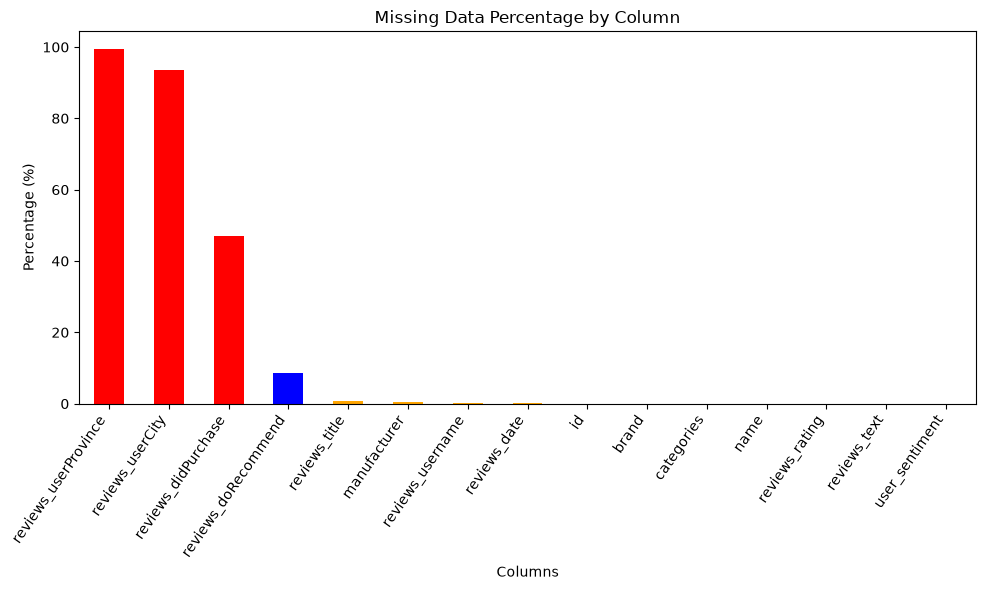

In [351]:
# Visualize missing-value percentages to quickly identify problematic columns.
colors = [
    "skyblue" if level == "No" else
    "orange" if level == "Low" else
    "red" if level == "High" else
    "blue"
    for level in missing_summary["Missing Level"]
]

missing_summary["Missing Percentage"].plot(
    kind="bar",
    figsize=(10, 6),
    color=colors,
)

plt.title("Missing Data Percentage by Column")
plt.ylabel("Percentage (%)")
plt.xlabel("Columns")
plt.xticks(rotation=55, ha="right")
plt.tight_layout()
plt.show()

#### Data Cleaning 

- Remove the columns 'reviews_userProvince', 'reviews_userCity', 'reviews_didPurchase' with high missing counts in the data cleaning stage

In [352]:
# Remove the columns 'reviews_userProvince', 'reviews_userCity', 'reviews_didPurchase'

#For cleaning and preprocessing, work on a separate copy to avoid accidental modifications to the original dataframe.
reviews_df_cleaned = reviews.copy()

reviews_df_cleaned.drop(
    columns=[
        'reviews_userProvince',
        'reviews_userCity',
        'reviews_didPurchase'
    ],
    inplace=True
)

reviews_df_cleaned.info()

<class 'pandas.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   id                   30000 non-null  str   
 1   brand                30000 non-null  str   
 2   categories           30000 non-null  str   
 3   manufacturer         29859 non-null  str   
 4   name                 30000 non-null  str   
 5   reviews_date         29954 non-null  str   
 6   reviews_doRecommend  27430 non-null  object
 7   reviews_rating       30000 non-null  int64 
 8   reviews_text         30000 non-null  str   
 9   reviews_title        29810 non-null  str   
 10  reviews_username     29937 non-null  str   
 11  user_sentiment       29999 non-null  str   
dtypes: int64(1), object(1), str(10)
memory usage: 2.7+ MB


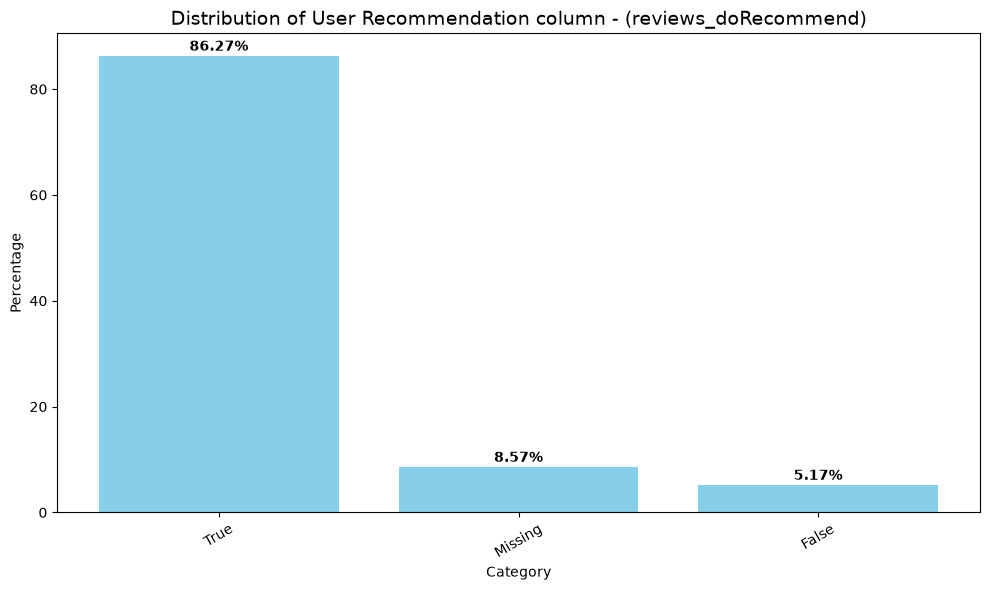

In [353]:
def plot_cat_distribution(df, column, title=None):
    # Create a clean plotting series without modifying the original dataframe
    series = df[column].fillna("Missing").astype(str)

    percentage_data = (
        series
        .value_counts(normalize=True)
        .mul(100)
        .round(2)
        .sort_values(ascending=False)
    )

    plt.figure(figsize=(10, 6))

    bars = plt.bar(
        percentage_data.index.astype(str),
        percentage_data.values,
        color="skyblue"
    )

    # Annotate percentage on top of each bar
    for bar, val in zip(bars, percentage_data.values):
        plt.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 1,
            f"{val:.2f}%",
            ha="center",
            fontweight="bold"
        )

    plt.title(title or f"Distribution of {column}", fontsize=14)
    plt.ylabel("Percentage")
    plt.xlabel("Category")
    plt.xticks(rotation=30)
    plt.tight_layout()
    plt.show()


plot_cat_distribution(reviews_df, "reviews_doRecommend", "Distribution of User Recommendation column - (reviews_doRecommend)")    

#### Data Cleaning

- Upon examining the distribution of the reviews_doRecommend column, we observe that over 86% of the entries are marked as True and 8% marked as Missing. This indicates a strong imbalance, providing little discriminatory power for the model. Therefore, this column will be dropped from the dataset.

In [354]:
# Remove the columns 'reviews_doRecommend'
reviews_df_cleaned.drop(columns=['reviews_doRecommend'], inplace=True)
reviews_df_cleaned.info()

<class 'pandas.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   id                30000 non-null  str  
 1   brand             30000 non-null  str  
 2   categories        30000 non-null  str  
 3   manufacturer      29859 non-null  str  
 4   name              30000 non-null  str  
 5   reviews_date      29954 non-null  str  
 6   reviews_rating    30000 non-null  int64
 7   reviews_text      30000 non-null  str  
 8   reviews_title     29810 non-null  str  
 9   reviews_username  29937 non-null  str  
 10  user_sentiment    29999 non-null  str  
dtypes: int64(1), str(10)
memory usage: 2.5 MB


In [355]:
missing_summary = get_missing_summary(reviews_df_cleaned)

display_info("Missing Values Summary", "Reviews dataframe")
display(missing_summary.style.format({
    "Missing Percentage": "{:.2f}%"
}))

--------------------------------------------------
Reviews dataframe: Missing Values Summary
--------------------------------------------------


,Missing Count,Missing Percentage,Missing Level
reviews_title,190,0.63%,Low
manufacturer,141,0.47%,Low
reviews_username,63,0.21%,Low
reviews_date,46,0.15%,Low
id,0,0.00%,No
brand,0,0.00%,No
categories,0,0.00%,No
name,0,0.00%,No
reviews_rating,0,0.00%,No
reviews_text,0,0.00%,No


 #### Data Cleaning
 - Since the missing values for the columns reviews_title, manufacturer	, reviews_username is less than 1% we will drop the rows with missing values

In [356]:
#drop rows with missing values in reviews_username & user_sentiment columns

columns_to_check = ['reviews_username', 'manufacturer','reviews_title']

def drop_rows_with_missing_values(df, columns):
    """
    Drops rows from the dataframe where any of the specified columns have missing values.

    Returns the count of missing rows per column before dropping, plus the total rows removed.
    """
    missing_counts = df[columns].isna().sum()
    rows_before = len(df)
    df.dropna(subset=columns, inplace=True)
    rows_after = len(df)
    return missing_counts, rows_before - rows_after

missing_counts, total_dropped = drop_rows_with_missing_values(reviews_df_cleaned, columns_to_check)

display_info("Missing values per column before dropping rows")
print(missing_counts)
display_info(total_dropped, "Total rows dropped after dropna")


--------------------------------------------------
Missing values per column before dropping rows
--------------------------------------------------
reviews_username     63
manufacturer        141
reviews_title       190
dtype: int64
--------------------------------------------------
Total rows dropped after dropna: 393
--------------------------------------------------


#### ! Observations & Conclusions:

Columns dropped in data cleaning stage 
 - reviews_userProvince
 - reviews_userCity
 - reviews_didPurchase
 - reviews_doRecommend

Rows Cleaned 
 - reviews_username :   63
 - manufacturer     :   141
 - reviews_title    :   190



Because reviews_username is the user identifier, it should not be imputed. Filling missing values with "Unknown" would incorrectly treat all 63 reviews as belonging to one user and distort collaborative filtering.
The 63 values are NaN and represent only 0.21% of the 30,000 rows.
We  drop those rows. Dropping the 63 rows entirely is also reasonable because the loss is only 0.21%.

Since the missing values for the columns reviews_title, manufacturer, reviews_username is less than 1% we  droped the rows with missing values

### 2.4. Sentiment Distribution

- Count positive and negative sentiment records.
- Plot the sentiment class distribution.
- Check whether the sentiment target is imbalanced.
- Compare sentiment distribution against review ratings.

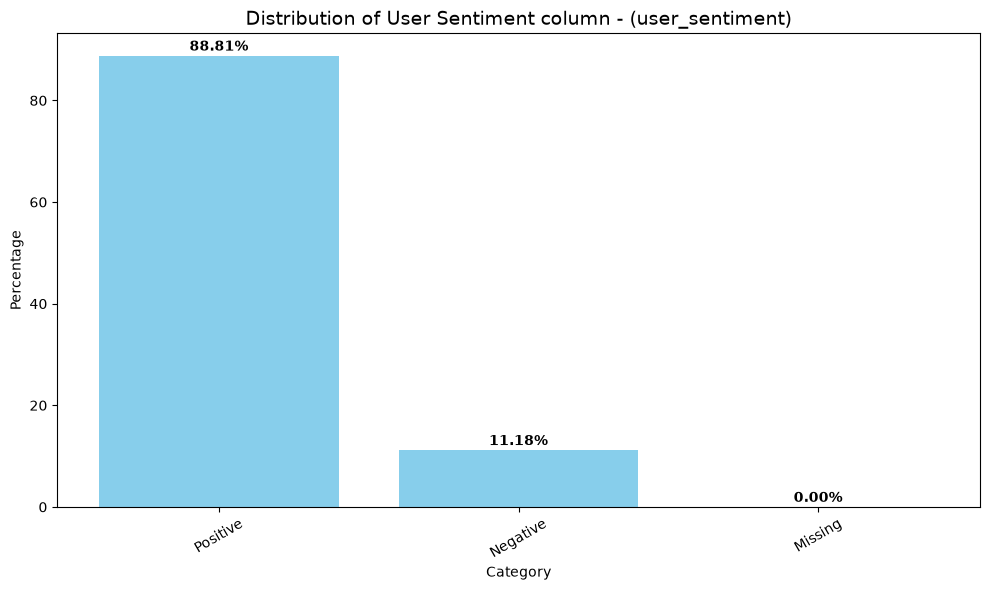

In [357]:
plot_cat_distribution(reviews_df_cleaned, "user_sentiment", "Distribution of User Sentiment column - (user_sentiment)")    

### 2.5. Ratings Analysis

- Analyze the distribution of `reviews_rating`.
- Calculate average, minimum, and maximum ratings.
- Count reviews by each rating value.
- Compare ratings with `user_sentiment`.
- Identify mismatch cases, such as high rating with negative sentiment or low rating with positive sentiment.

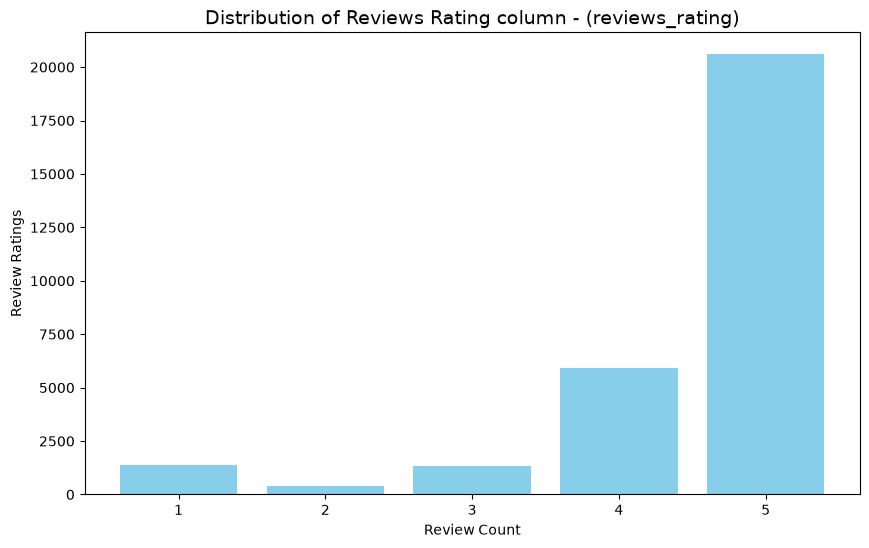

--------------------------------------------------
Average Rating:: 4.485797277670821
--------------------------------------------------
--------------------------------------------------
Minimum Rating:: 1
--------------------------------------------------
--------------------------------------------------
Maximum Rating:: 5
--------------------------------------------------
--------------------------------------------------
Review Counts by Rating Value: 
--------------------------------------------------
Reviews with 1 stars: 1359
Reviews with 2 stars: 407
Reviews with 3 stars: 1315
Reviews with 4 stars: 5937
Reviews with 5 stars: 20589
--------------------------------------------------
Compare ratings with sentiments: 
--------------------------------------------------


user_sentiment,Negative,Positive
reviews_rating,,
1,42.97%,57.03%
2,33.66%,66.34%
3,16.20%,83.80%
4,9.04%,90.96%
5,8.94%,91.06%


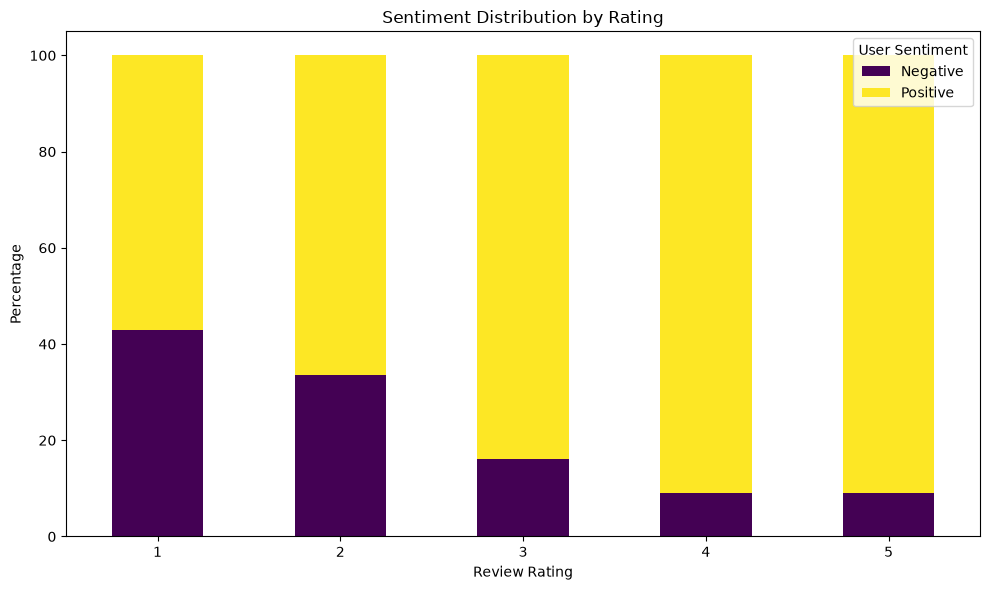

In [358]:
# analyze the distribution of reviews_rating to understand the rating scale and its impact on sentiment and recommendation modeling.

def plot_cat_distribution(df, column, title=None):
    # Create a clean plotting series without modifying the original dataframe
    series = df[column].fillna("Missing").astype(str)
    plt.figure(figsize=(10, 6))     
    plt.bar(series.value_counts().sort_index().index.astype(str), series.value_counts().sort_index().values, color="skyblue")   
    plt.title(title or f"Distribution of {column}", fontsize=14)
    plt.ylabel("Review Ratings")
    plt.xlabel("Review Count")
    plt.show()

plot_cat_distribution(reviews_df_cleaned, "reviews_rating", "Distribution of Reviews Rating column - (reviews_rating)")

# Calculate average, minimum, and maximum ratings
avg_rating = reviews_df_cleaned["reviews_rating"].mean()
min_rating = reviews_df_cleaned["reviews_rating"].min()
max_rating = reviews_df_cleaned["reviews_rating"].max()

display_info(avg_rating, "Average Rating:")
display_info(min_rating, "Minimum Rating:")
display_info(max_rating, "Maximum Rating:")

#Count reviews by each rating value.
rating_counts = reviews_df_cleaned["reviews_rating"].value_counts().sort_index()
display_info("", "Review Counts by Rating Value")
for rating, count in rating_counts.items():
    print(f"Reviews with {rating} stars: {count}")


#Compare ratings with sentiments 
display_info("", "Compare ratings with sentiments")

rating_sentiment_counts = pd.crosstab(
    reviews_df_cleaned["reviews_rating"],
    reviews_df_cleaned["user_sentiment"],
    margins=True
)
rating_sentiment_counts

#Compare ratings with sentiments (percentage)
rating_sentiment_counts_per = pd.crosstab(
    reviews_df_cleaned["reviews_rating"],
    reviews_df_cleaned["user_sentiment"],
    normalize="index",
).mul(100).round(2)

# Show formatted percentages without requiring jinja2
display(rating_sentiment_counts_per.style.format("{:.2f}%"))

# plot the distribution of user sentiment across different review ratings to visualize how sentiment varies with rating values.

rating_sentiment_counts_per.plot(
    kind="bar",
    stacked=True,
    figsize=(10, 6),
    colormap="viridis"
)

plt.title("Sentiment Distribution by Rating")
plt.xlabel("Review Rating")
plt.ylabel("Percentage")
plt.xticks(rotation=0)
plt.legend(title="User Sentiment")
plt.tight_layout()
plt.show()

In [359]:
# Identify mismatch cases, such as high rating with negative sentiment or low rating with positive sentiment.
high_rating_negative = reviews_df_cleaned[
    (reviews_df_cleaned["reviews_rating"] >= 4) &
    (reviews_df_cleaned["user_sentiment"] == "Negative")
]

low_rating_positive = reviews_df_cleaned[
    (reviews_df_cleaned["reviews_rating"] <= 2) &
    (reviews_df_cleaned["user_sentiment"] == "Positive")
]
#display_info("","Identify mismatch cases, such as high rating with negative sentiment or low rating with positive sentiment.")
display_info(high_rating_negative.shape[0], "High rating but negative sentiment:")
display(high_rating_negative.groupby(["reviews_rating"]).count().user_sentiment)

display_info(low_rating_positive.shape[0], "Low rating but positive sentiment:")
display(low_rating_positive.groupby(["reviews_rating"]).count().user_sentiment)


--------------------------------------------------
High rating but negative sentiment:: 2377
--------------------------------------------------


reviews_rating
4     537
5    1840
Name: user_sentiment, dtype: int64

--------------------------------------------------
Low rating but positive sentiment:: 1045
--------------------------------------------------


reviews_rating
1    775
2    270
Name: user_sentiment, dtype: int64

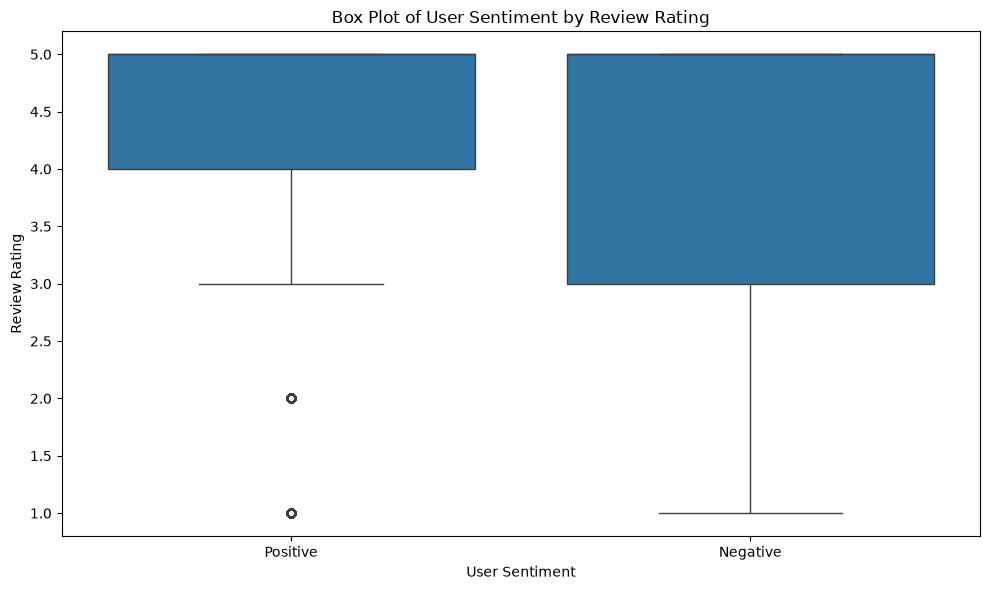

In [360]:
def box_plot_sentiment_by_rating(df):
    plt.figure(figsize=(10, 6))
    sns.boxplot( x="user_sentiment",y="reviews_rating", data=df)
    plt.title("Box Plot of User Sentiment by Review Rating")
    plt.ylabel("Review Rating")
    plt.xlabel("User Sentiment")
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.show()

box_plot_sentiment_by_rating(reviews_df_cleaned)    

#### Data Cleaning
 - Fix  High rating classified as negative sentiment and Low rating classified as positive sentiment

In [361]:
# Fix  High rating classified as negative sentiment
# Change the  sentiment of reviews with high ratings (4 or 5) but negative sentiment to positive sentiment.
reviews_df_cleaned.loc[high_rating_negative.index, "user_sentiment"] = "Positive"

# Fix  Low rating classified as positive sentiment
# Change the  sentiment of reviews with low ratings (1 or 2) but positive sentiment to negative sentiment.
reviews_df_cleaned.loc[low_rating_positive.index, "user_sentiment"] = "Negative"

In [362]:
# Identify mismatch cases, such as high rating with negative sentiment or low rating with positive sentiment.
high_rating_negative = reviews_df_cleaned[
    (reviews_df_cleaned["reviews_rating"] >= 4) &
    (reviews_df_cleaned["user_sentiment"] == "Negative")
]

low_rating_positive = reviews_df_cleaned[
    (reviews_df_cleaned["reviews_rating"] <= 2) &
    (reviews_df_cleaned["user_sentiment"] == "Positive")
]
#display_info("","Identify mismatch cases, such as high rating with negative sentiment or low rating with positive sentiment.")
display_info(high_rating_negative.shape[0], "High rating but negative sentiment:")
display(high_rating_negative.groupby(["reviews_rating"]).count().user_sentiment)

display_info(low_rating_positive.shape[0], "Low rating but positive sentiment:")
display(low_rating_positive.groupby(["reviews_rating"]).count().user_sentiment)

--------------------------------------------------
High rating but negative sentiment:: 0
--------------------------------------------------


Series([], Name: user_sentiment, dtype: int64)

--------------------------------------------------
Low rating but positive sentiment:: 0
--------------------------------------------------


Series([], Name: user_sentiment, dtype: int64)

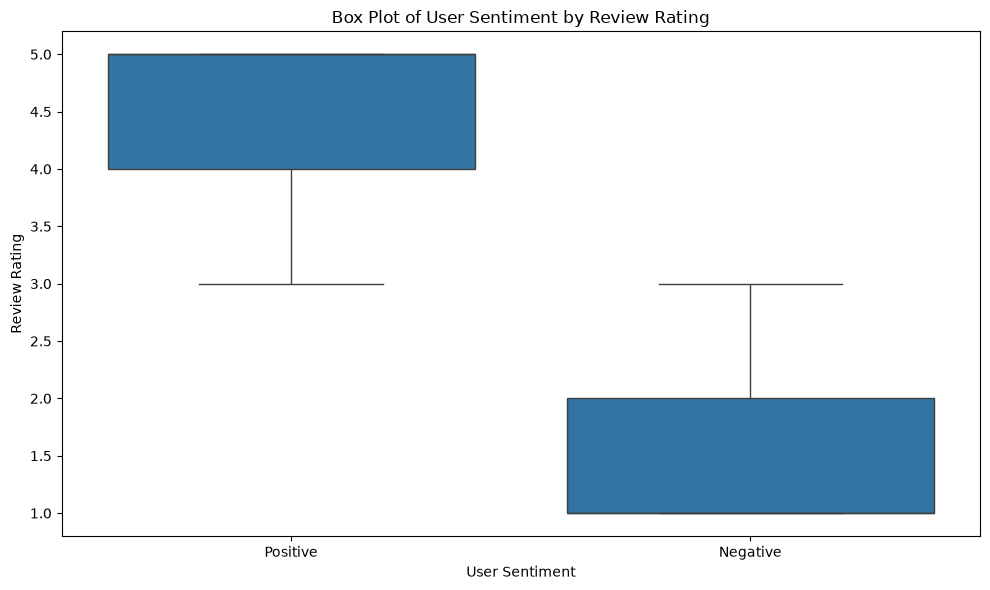

In [363]:
box_plot_sentiment_by_rating(reviews_df_cleaned)

#### ! Observations & Conclusions:

 - There were inconsistencies where low ratings were marked positive and high ratings were marked negative. Therefore, ratings if used for as an input feature for sentiment classification would lead to target leakage, so this misclassification has been handled.

 - The ratings are highly skewed toward positive reviews, with '5' ratings being the most common. The average rating is 4.48, indicating that most users rated products favorably. Sentiment generally follows the rating pattern, as '4' and '5' reviews are mostly positive. 
 
 - This indicates a potential class imbalance, which could affect model performance especially since user_sentiment is expected to align closely with these ratings. We will need to handle this class imbalance. 

1. EDA 
2. Lexical Processing:
 Data Cleaning
    Punctuation Removal
    Stopword Removal
    Stemming/Lemmitaization
    common Words
    Sparse word removal
    Spell check

3. Tokenization
   Count Vecrorizer
    Bag Of Words
    TF-IDF - prefer
    Word2Vec - prefer
    Glove embeddings
4. Manage Data Imbalance
    oversapmling - imblearn package - RandomOverSampler
    undersampling
    smote - use this do after tokenization , if doing befor smote will fail on natural data imblearn.over_sampling import SMOTE
    algo linked techniques
5. Make a table , pick 4 algos and compare imbalanced vs balanced data (without & with different balancing technique). Preceision & recall record in table. Metrics to follow precision , recall, **sensitivity**, **specificuity** , auc, prauc, f1 score 
Logistic Regression
NaiveBiase
RandomForest
Decision Tree
Boosting
    XGBoost
    GBM
SVM
KNN
6. Hyperparameter Tuning - Tips
    - keep parametre space limited
    - if grid search is taking time use random search, 
7. manage oversampling with logistc & xgboost, manage weight of minority class



Sentiment Anamysis - Cols [review_ratings, rerview_text,review_title]


### 2.6. Duplicate Analysis

- Check for fully duplicate rows.
- Check repeated user-product-review combinations.

In [364]:
# Count rows that are completely identical across all columns.
# These can usually be removed because they add no new information.
full_duplicate_count = reviews.duplicated().sum()

print("Fully duplicated rows:", full_duplicate_count)

Fully duplicated rows: 0


In [365]:
# Inspect full duplicates before dropping them to confirm they are truly repeated records.
full_duplicates = reviews[
    reviews.duplicated(keep=False)
].sort_values("id")

full_duplicates.head(10)

,id,brand,categories,manufacturer,name,reviews_date,reviews_didPurchase,reviews_doRecommend,reviews_rating,reviews_text,reviews_title,reviews_userCity,reviews_userProvince,reviews_username,user_sentiment


In [366]:
# Check unique product ID coverage.
# In this dataset, id behaves as a product identifier, so repeated IDs are expected.
print("Total rows:", len(reviews))
print("Unique Product IDs:", reviews["id"].nunique())
print("Missing Product IDs:", reviews["id"].isna().sum())
print("Duplicated Product IDs:", reviews["id"].duplicated().sum())

Total rows: 30000
Unique Product IDs: 271
Missing Product IDs: 0
Duplicated Product IDs: 29729


In [367]:
# Validate whether each product ID maps consistently to a single product name.
# A non-zero result may indicate product naming inconsistencies that need cleanup.
product_names_per_id = reviews.groupby("id")["name"].nunique()

print(
    "Product IDs mapped to multiple product names:",
    (product_names_per_id > 1).sum()
)

Product IDs mapped to multiple product names: 0


In [368]:
# Check whether the same user reviewed the same product multiple times.
# These records should be inspected and later aggregated for collaborative filtering.
user_product_duplicates = reviews.duplicated(
    subset=["reviews_username", "id"],
    keep=False,
)

print(
    "Rows with repeated user-product combinations:",
    user_product_duplicates.sum()
)

Rows with repeated user-product combinations: 4569


In [369]:
# Review repeated user-product records to decide whether they are true duplicates
# or multiple valid reviews/ratings for the same product by the same user.
repeated_user_products = reviews[
    user_product_duplicates
].sort_values(["reviews_username", "id", "reviews_date"])

repeated_user_products[
    [
        "reviews_username",
        "id",
        "name",
        "reviews_date",
        "reviews_rating",
        "reviews_text",
        "user_sentiment",
    ]
].head(100)

,reviews_username,id,name,reviews_date,reviews_rating,reviews_text,user_sentiment
14290,1234567,AVpf3VOfilAPnD_xjpun,Clorox Disinfecting Wipes Value Pack Scented 1...,2014-12-06T00:00:00.000Z,5,This is a good product to use if you're in a h...,Positive
9170,1234567,AVpf3VOfilAPnD_xjpun,Clorox Disinfecting Wipes Value Pack Scented 1...,2014-12-06T18:01:21.000Z,5,This is a good product to use if you're in a h...,Positive
28843,1234asdf,AVpfW8y_LJeJML437ySW,L'or233al Paris Elvive Extraordinary Clay Reba...,2017-01-11T00:00:00.000Z,2,I got this product free and was very excited t...,Positive
28866,1234asdf,AVpfW8y_LJeJML437ySW,L'or233al Paris Elvive Extraordinary Clay Reba...,2017-01-11T14:00:32.000Z,2,I got this product free and was very excited t...,Positive
5852,143st,AVpf2tw1ilAPnD_xjflC,Red (special Edition) (dvdvideo),2013-09-07T00:00:00.000Z,5,I orderd on line and picked it up at the CS De...,Positive
...,...,...,...,...,...,...,...
6585,akesler19,AVpf3VOfilAPnD_xjpun,Clorox Disinfecting Wipes Value Pack Scented 1...,2015-02-11T14:56:50.000Z,4,We use Clorox wipes at my work every day when ...,Negative
4669,akhan,AVpf0eb2LJeJML43EVSt,The Resident Evil Collection 5 Discs (blu-Ray),2017-02-12T00:00:00.000Z,4,A great purchase. All the movies in one bundle...,Positive
5309,akhan,AVpf0eb2LJeJML43EVSt,The Resident Evil Collection 5 Discs (blu-Ray),2017-05-28T00:00:00.000Z,5,A great bundle with all the movies. This was a...,Positive
20455,akporter84,AVpfJP1C1cnluZ0-e3Xy,Clorox Disinfecting Bathroom Cleaner,2012-01-26T00:00:00.000Z,5,I like the smell of the product after I clean....,Positive


In [370]:
# pd.set_option('display.max_rows', None)
# pd.set_option('display.max_columns', None)
# pd.set_option('display.width', None)
# pd.set_option('display.max_colwidth', None)
# display(repeated_user_products[[
#         "reviews_username",
#         "id",
#         "name",
#         "reviews_date",
#         "reviews_rating",
#         "reviews_text",
#         "user_sentiment",
#     ]])

In [371]:
# Check exact review-level repetitions using the fields that define a repeated review event.
review_key = [
    "reviews_username",
    "id",
    "reviews_rating",
    "reviews_text",
]

exact_review_duplicates = reviews.duplicated(
    subset=review_key,
    keep=False,
)

print(
    "Repeated user-product-rating-text rows:",
    exact_review_duplicates.sum()
)

Repeated user-product-rating-text rows: 3584


### 2.7. Product-Level Analysis

- Count unique products.
- Identify the most reviewed products.
- Calculate average rating by product.
- Check sentiment distribution by product.
- Identify products with high review volume and low average rating.
- Identify products with many negative reviews.

In [372]:
#count unique products

# count unique products
unique_products = reviews_df_cleaned["name"].nunique()
display_info(unique_products, "Unique products:")

# Optionally show review counts per product
product_counts = reviews_df_cleaned["name"].value_counts()
display(product_counts)

--------------------------------------------------
Unique products:: 251
--------------------------------------------------


name
Clorox Disinfecting Wipes Value Pack Scented 150 Ct Total                         8524
Godzilla 3d Includes Digital Copy Ultraviolet 3d/2d Blu-Ray/dvd                   3324
Clorox Disinfecting Bathroom Cleaner                                              2039
L'or233al Paris Elvive Extraordinary Clay Rebalancing Conditioner - 12.6 Fl Oz    1186
Planes: Fire Rescue (2 Discs) (includes Digital Copy) (blu-Ray/dvd)               1140
                                                                                  ... 
5302050 15/16 FCT/HOSE ADAPTOR                                                       1
High-Dome Floor Door Stop                                                            1
Tostitos Original Restaurant Style Tortilla Chips                                    1
Walkers Stem Ginger Shortbread                                                       1
Bodycology Nourishing Body Cream, Pretty In Paris                                    1
Name: count, Length: 251, dtype: int64

--------------------------------------------------
Top 30 Reviewed Products:: 
--------------------------------------------------


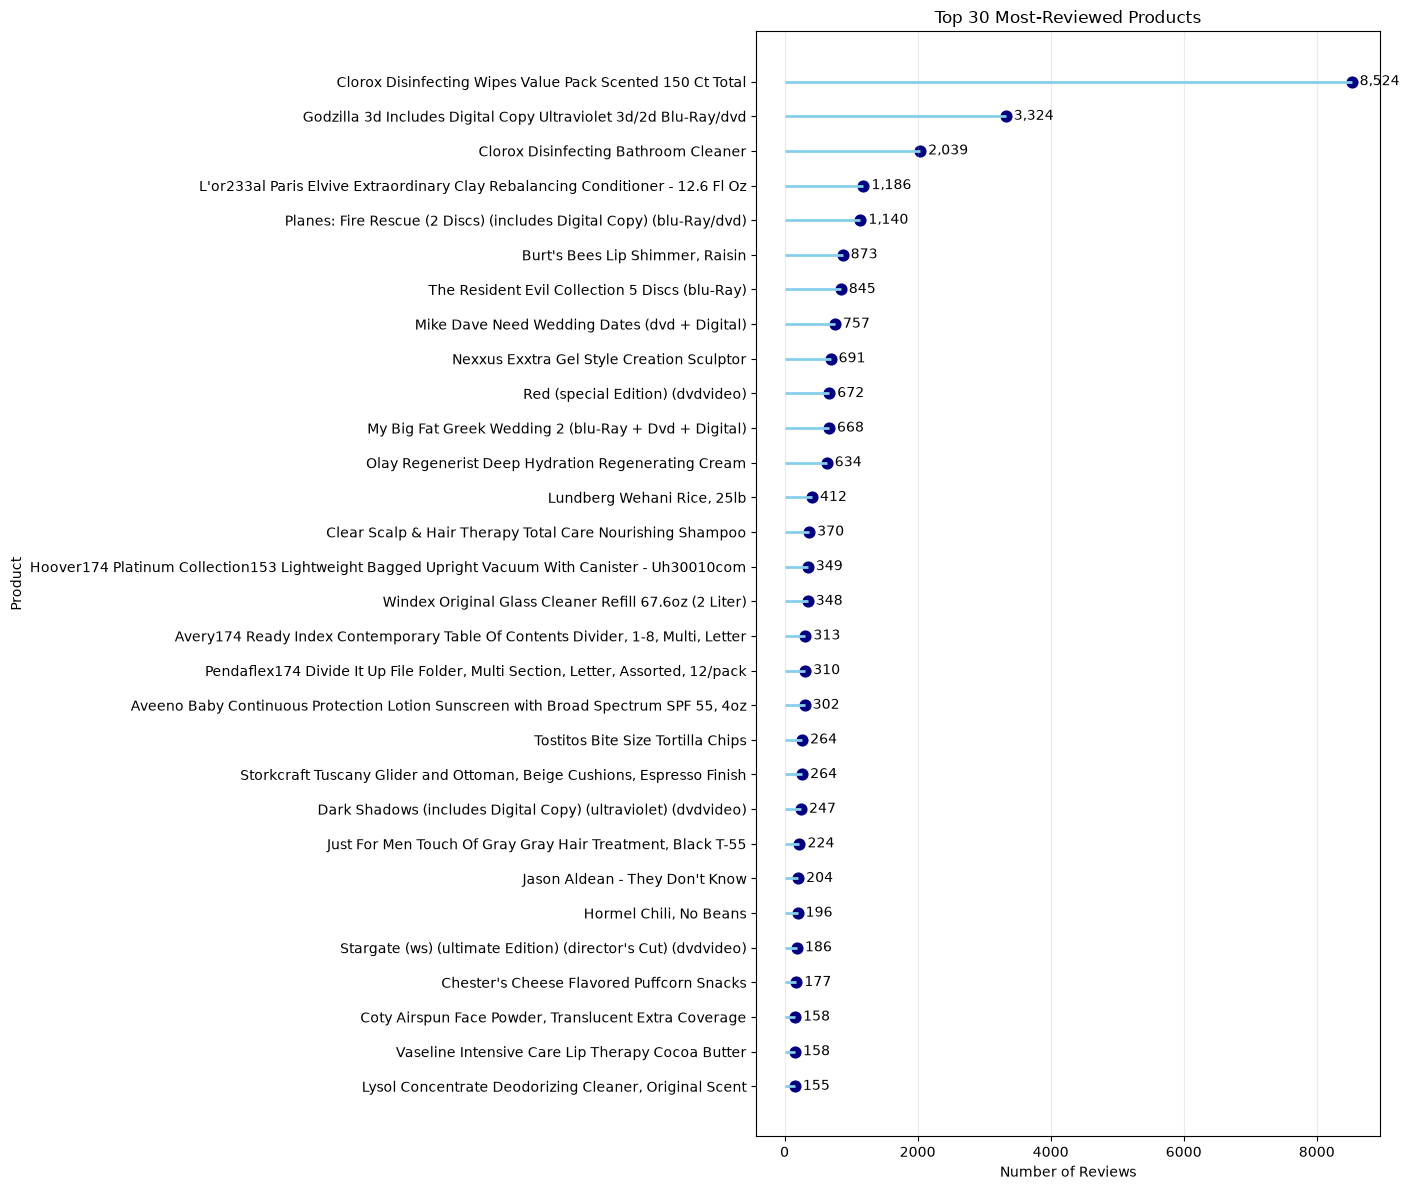

In [373]:
# top reviewed products
top_n = 30
top_reviewed_products = (
    reviews_df_cleaned
    .groupby(["id","name"], as_index=False)
    .agg(reviews_count=("reviews_text", "count"))
    .sort_values(by="reviews_count", ascending=False)
)
display_info("", f"Top {top_n} Reviewed Products:")
#display(top_reviewed_products.head(top_n))


plot_data = (
    top_reviewed_products
    .head(top_n)
    .sort_values("reviews_count")
)

plt.figure(figsize=(14, 12))

plt.hlines(
    y=plot_data["name"],
    xmin=0,
    xmax=plot_data["reviews_count"],
    color="skyblue",
    linewidth=2
)

plt.scatter(
    plot_data["reviews_count"],
    plot_data["name"],
    color="navy",
    s=60
)

for _, row in plot_data.iterrows():
    plt.text(
        row["reviews_count"],
        row["name"],
        f"  {row['reviews_count']:,}",
        va="center"
    )

plt.title(f"Top {top_n} Most-Reviewed Products")
plt.xlabel("Number of Reviews")
plt.ylabel("Product")
plt.grid(axis="x", alpha=0.25)
plt.tight_layout()
plt.show()

--------------------------------------------------
Average Rating by Product: 
--------------------------------------------------


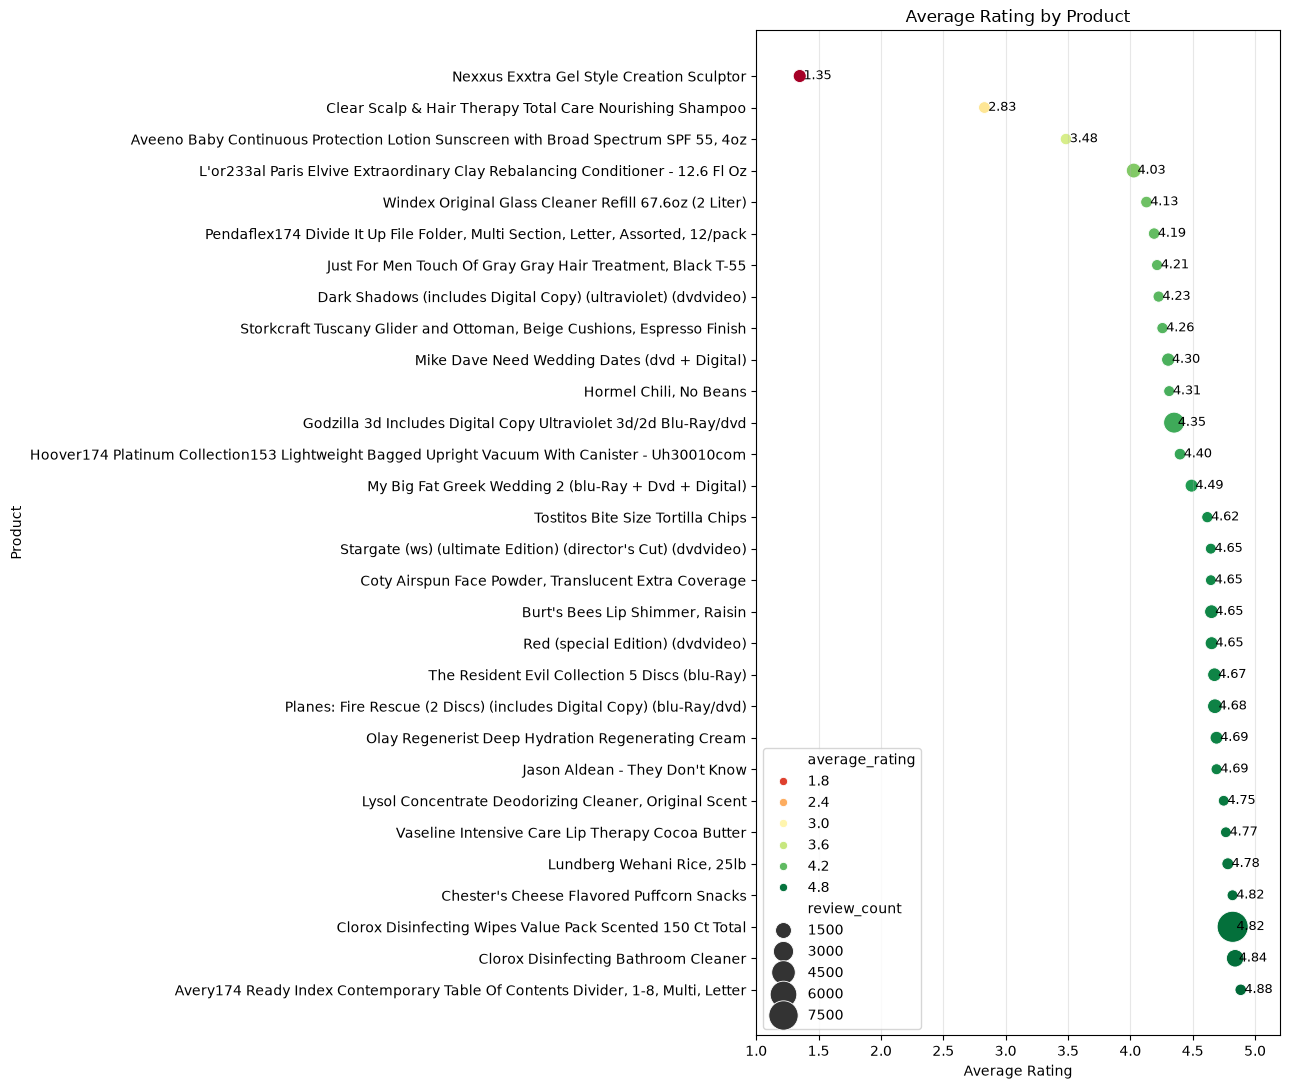

In [374]:
display_info("","Average Rating by Product")

product_rating_summary = (
    reviews_df_cleaned
    .groupby(["id", "name"], as_index=False)
    .agg(
        average_rating=("reviews_rating", "mean"),
        review_count=("reviews_rating", "count")
    )
)

# Keep products with enough reviews for a reliable average
plot_data = (
    product_rating_summary
    .query("review_count >= 20")
    .nlargest(30, "review_count")
    .sort_values("average_rating")
)

plt.figure(figsize=(13, 11))

ax = sns.scatterplot(
    data=plot_data,
    x="average_rating",
    y="name",
    size="review_count",
    hue="average_rating",
    palette="RdYlGn",
    sizes=(60, 500),
    legend="brief"
)

for _, row in plot_data.iterrows():
    ax.text(
        row["average_rating"] + 0.03,
        row["name"],
        f'{row["average_rating"]:.2f}',
        va="center",
        fontsize=9
    )

plt.xlim(1, 5.2)
plt.title("Average Rating by Product")
plt.xlabel("Average Rating")
plt.ylabel("Product")
plt.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

--------------------------------------------------
Sentiment Distribution of Top 30 Most-Reviewed Products: 
--------------------------------------------------


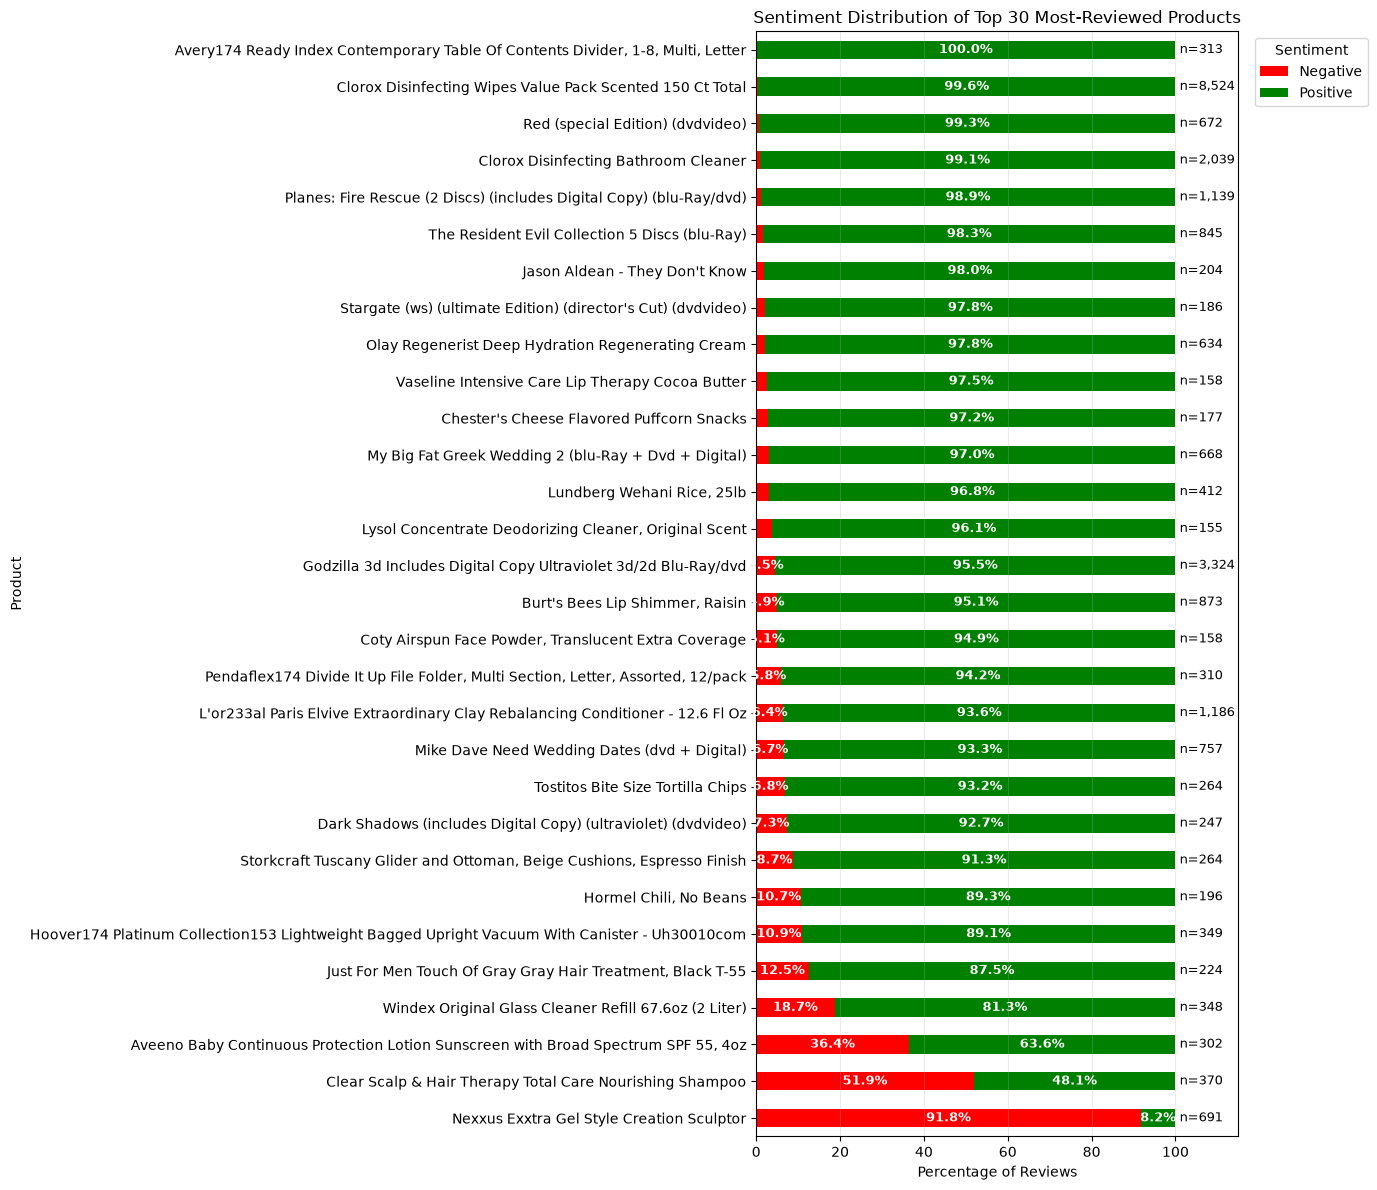

In [375]:
top_n = 30
display_info("",f"Sentiment Distribution of Top {top_n} Most-Reviewed Products")
# Count sentiments for each product
product_sentiment = (
    reviews_df_cleaned
    .groupby(["id", "name", "user_sentiment"])
    .size()
    .unstack(fill_value=0)
    .reset_index()
)

# Ensure both sentiment columns exist
for sentiment in ["Positive", "Negative"]:
    if sentiment not in product_sentiment.columns:
        product_sentiment[sentiment] = 0

product_sentiment["reviews_count"] = (
    product_sentiment["Positive"]
    + product_sentiment["Negative"]
)

# Select the top-reviewed products
plot_data = (
    product_sentiment
    .nlargest(top_n, "reviews_count")
    .copy()
)

# Convert sentiment counts into percentages
sentiment_percentage = (
    plot_data
    .set_index("name")[["Negative", "Positive"]]
)

sentiment_percentage = sentiment_percentage.div(
    sentiment_percentage.sum(axis=1),
    axis=0
).mul(100)

# Sort by positive sentiment percentage
sentiment_percentage = sentiment_percentage.sort_values("Positive")

review_counts = (
    plot_data
    .set_index("name")["reviews_count"]
    .reindex(sentiment_percentage.index)
)

ax = sentiment_percentage.plot(
    kind="barh",
    stacked=True,
    figsize=(14, 12),
    color={
        "Negative": "Red",
        "Positive": "Green"
    }
)

# Display percentages inside the bars
for container in ax.containers:
    labels = [
        f"{value:.1f}%" if value >= 4 else ""
        for value in container.datavalues
    ]

    ax.bar_label(
        container,
        labels=labels,
        label_type="center",
        color="white",
        fontsize=9,
        fontweight="bold"
    )

# Display total review count after each bar
for position, count in enumerate(review_counts):
    ax.text(
        101,
        position,
        f"n={count:,}",
        va="center",
        fontsize=9
    )

plt.title(f"Sentiment Distribution of Top {top_n} Most-Reviewed Products")
plt.xlabel("Percentage of Reviews")
plt.ylabel("Product")
plt.xlim(0, 115)
plt.legend(title="Sentiment", bbox_to_anchor=(1.02, 1))
plt.grid(axis="x", alpha=0.25)
plt.tight_layout()
plt.show()

--------------------------------------------------
Products with ≥20 Reviews and Lowest Average Rating: 
--------------------------------------------------


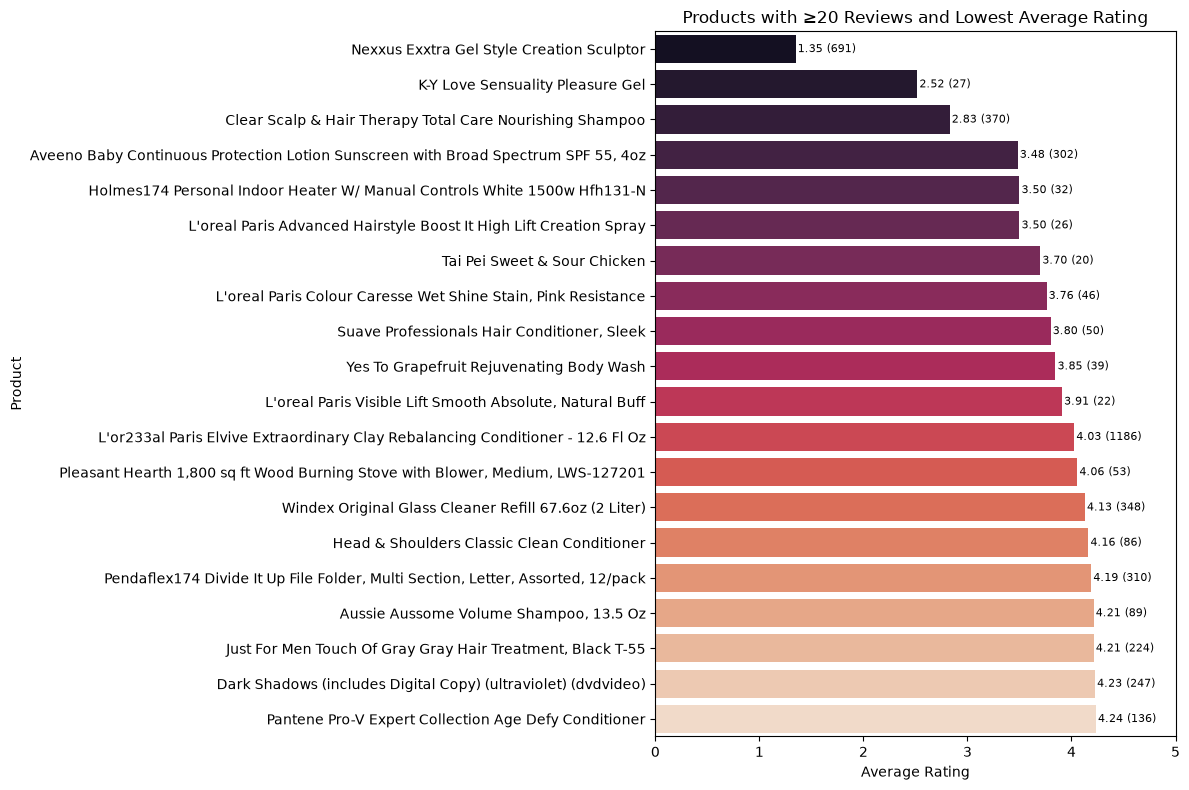

In [376]:
# Identify products with relatively high review volume and low average rating.

review_count_threshold = 20
display_info("",f"Products with ≥{review_count_threshold} Reviews and Lowest Average Rating")

low_rating_high_volume = (
    product_rating_summary
    .query("review_count >= @review_count_threshold")
    .sort_values(["average_rating", "review_count"], ascending=[True, False])
    .head(20)
)

#display(low_rating_high_volume)

plt.figure(figsize=(12, 8))
plot_data = low_rating_high_volume.sort_values("average_rating", ascending=True)

sns.barplot(
    data=plot_data,
    x="average_rating",
    y="name",
    hue="name",
    palette="rocket",
    legend = False
)

for idx, (rating, count) in enumerate(zip(plot_data["average_rating"], plot_data["review_count"])):
    plt.text(rating + 0.02, idx, f"{rating:.2f} ({count})", va="center", fontsize=8)

plt.title(f"Products with ≥{review_count_threshold} Reviews and Lowest Average Rating")
plt.xlabel("Average Rating")
plt.ylabel("Product")
plt.xlim(0, 5)
plt.tight_layout()
plt.show()

#plot the graph 



--------------------------------------------------
Top 20 Products by Negative Review Count: 
--------------------------------------------------


,id,name,negative_reviews,total_reviews,negative_pct
226,AVpfm8yiLJeJML43AYyu,Nexxus Exxtra Gel Style Creation Sculptor,634,691,91.751085
168,AVpfOmKwLJeJML435GM7,Clear Scalp & Hair Therapy Total Care Nourishi...,192,370,51.891892
173,AVpfPaoqLJeJML435Xk9,Godzilla 3d Includes Digital Copy Ultraviolet ...,150,3324,4.512635
172,AVpfPPkEilAPnD_xX3cP,Aveeno Baby Continuous Protection Lotion Sunsc...,110,302,36.423841
196,AVpfW8y_LJeJML437ySW,L'or233al Paris Elvive Extraordinary Clay Reba...,76,1186,6.408094
3,AV1YGDqsGV-KLJ3adc-O,Windex Original Glass Cleaner Refill 67.6oz (2...,65,348,18.678161
37,AVpe41TqilAPnD_xQH3d,Mike Dave Need Wedding Dates (dvd + Digital),51,757,6.737120
95,AVpf63aJLJeJML43F__Q,"Burt's Bees Lip Shimmer, Raisin",43,873,4.925544
68,AVpe9W4D1cnluZ0-avf0,Hoover174 Platinum Collection153 Lightweight B...,38,349,10.888252
86,AVpf3VOfilAPnD_xjpun,Clorox Disinfecting Wipes Value Pack Scented 1...,38,8524,0.445800


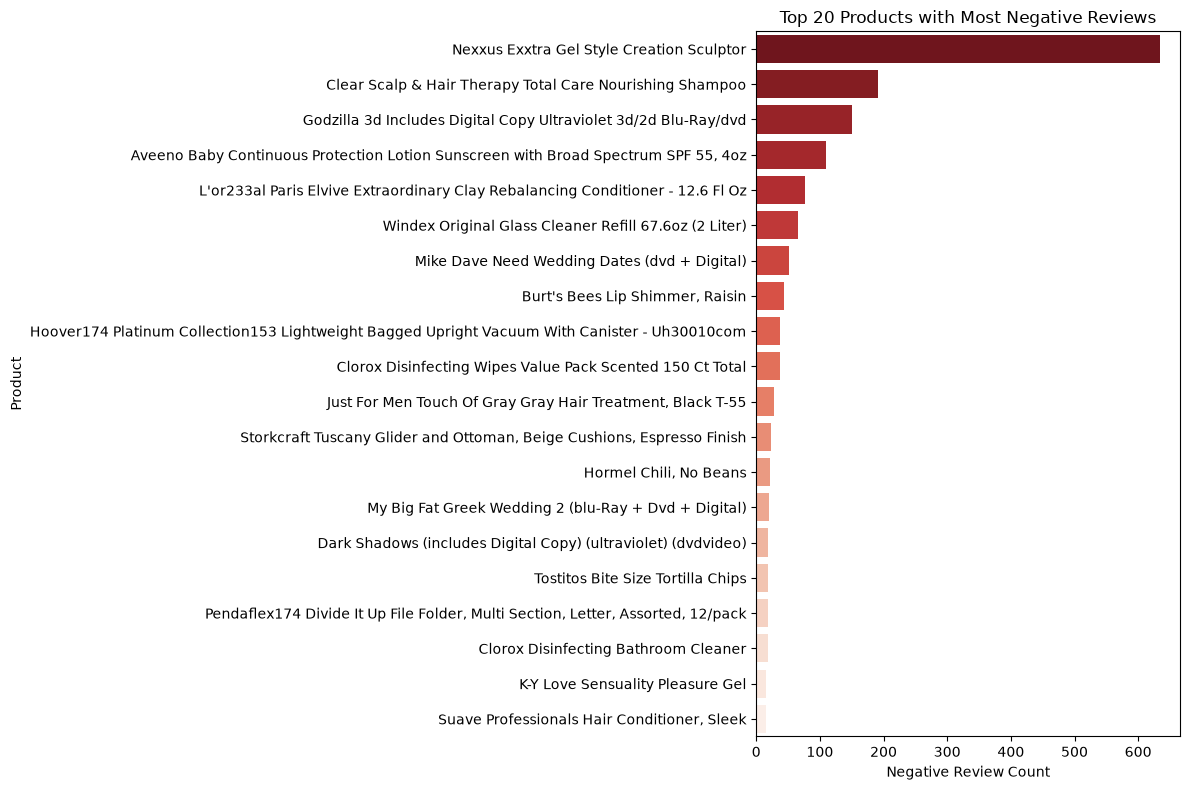

In [377]:
top_n = 20

product_negative_summary = (
    reviews_df_cleaned.assign(is_negative=lambda df: df["user_sentiment"] == "Negative")
    .groupby(["id", "name"], as_index=False)
    .agg(
        negative_reviews=("is_negative", "sum"),
        total_reviews=("user_sentiment", "count"),
    )
)

product_negative_summary["negative_pct"] = (
    product_negative_summary["negative_reviews"]
    / product_negative_summary["total_reviews"]
    * 100
)

top_negative_products = product_negative_summary.sort_values(
    by=["negative_reviews", "negative_pct"],
    ascending=[False, False],
).head(top_n)

display_info("", f"Top {top_n} Products by Negative Review Count")
display(top_negative_products)

plt.figure(figsize=(12, 8))
sns.barplot(
    data=top_negative_products,
    x="negative_reviews",
    y="name",
    hue="name",
    palette="Reds_r",
    legend=False
)
plt.title(f"Top {top_n} Products with Most Negative Reviews")
plt.xlabel("Negative Review Count")
plt.ylabel("Product")
plt.tight_layout()
plt.show()

 ### Observation

- *Avery174 Ready Index Contemporary Table Of Contents Divider, 1-8, Multi, Letter* - is the product with highest Average ratings 
- *Clorox Disinfecting Wipes Value Pack Scented 150 Ct Total* is the product with most no of reviews
- *Nexxus Exxtra Gel Style Creation Sculptor* - Is the product with most -ve reviews, is also product with high review volume and low average rating.





### 2.8. Brand and Category Analysis

- Identify top brands by review count.
- Calculate average rating by brand.
- Check sentiment distribution by brand.
- Identify common product categories.
- Compare category-level sentiment and rating patterns.

--------------------------------------------------
Top 20 Brands by Review Count: 
--------------------------------------------------


,brand,count,percent
0,Clorox,10564,35.68
1,Warner Home Video,3324,11.23
2,Disney,1197,4.04
3,L'oreal Paris,1186,4.01
4,FOX,887,3.00
5,Burt's Bees,881,2.98
6,Sony Pictures,845,2.85
7,Nexxus,691,2.33
8,Summit Entertainment,672,2.27
9,Universal Home Video,668,2.26


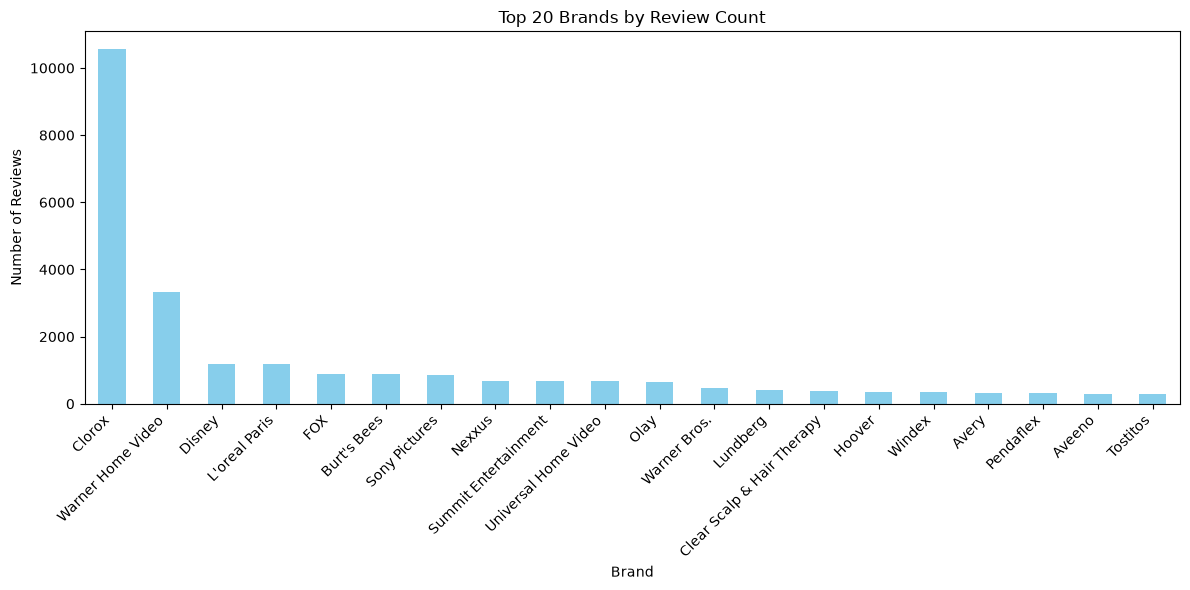

In [388]:
top_brands = (
    reviews_df_cleaned["brand"]
    .fillna("Unknown")
    .value_counts()
    .head(20)
    .rename_axis("brand")
    .reset_index(name="count")
)
total_brand_reviews = reviews_df_cleaned["brand"].fillna("Unknown").shape[0]
top_brands["percent"] = (top_brands["count"] / total_brand_reviews * 100).round(2)

display_info("", "Top 20 Brands by Review Count")
display(top_brands)

plt.figure(figsize=(12, 6))
top_brands.set_index("brand")["count"].plot(kind="bar", color="skyblue")
plt.title("Top 20 Brands by Review Count")
plt.ylabel("Number of Reviews")
plt.xlabel("Brand")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


--------------------------------------------------
Sentiment Percentage for Top 20 Brands
--------------------------------------------------


user_sentiment,Negative,Positive
brand,,
Clorox,0.53%,99.47%
Warner Home Video,4.51%,95.49%
Disney,1.00%,99.00%
L'oreal Paris,6.41%,93.59%
FOX,5.98%,94.02%
Burt's Bees,4.88%,95.12%
Sony Pictures,1.66%,98.34%
Nexxus,91.75%,8.25%
Summit Entertainment,0.74%,99.26%


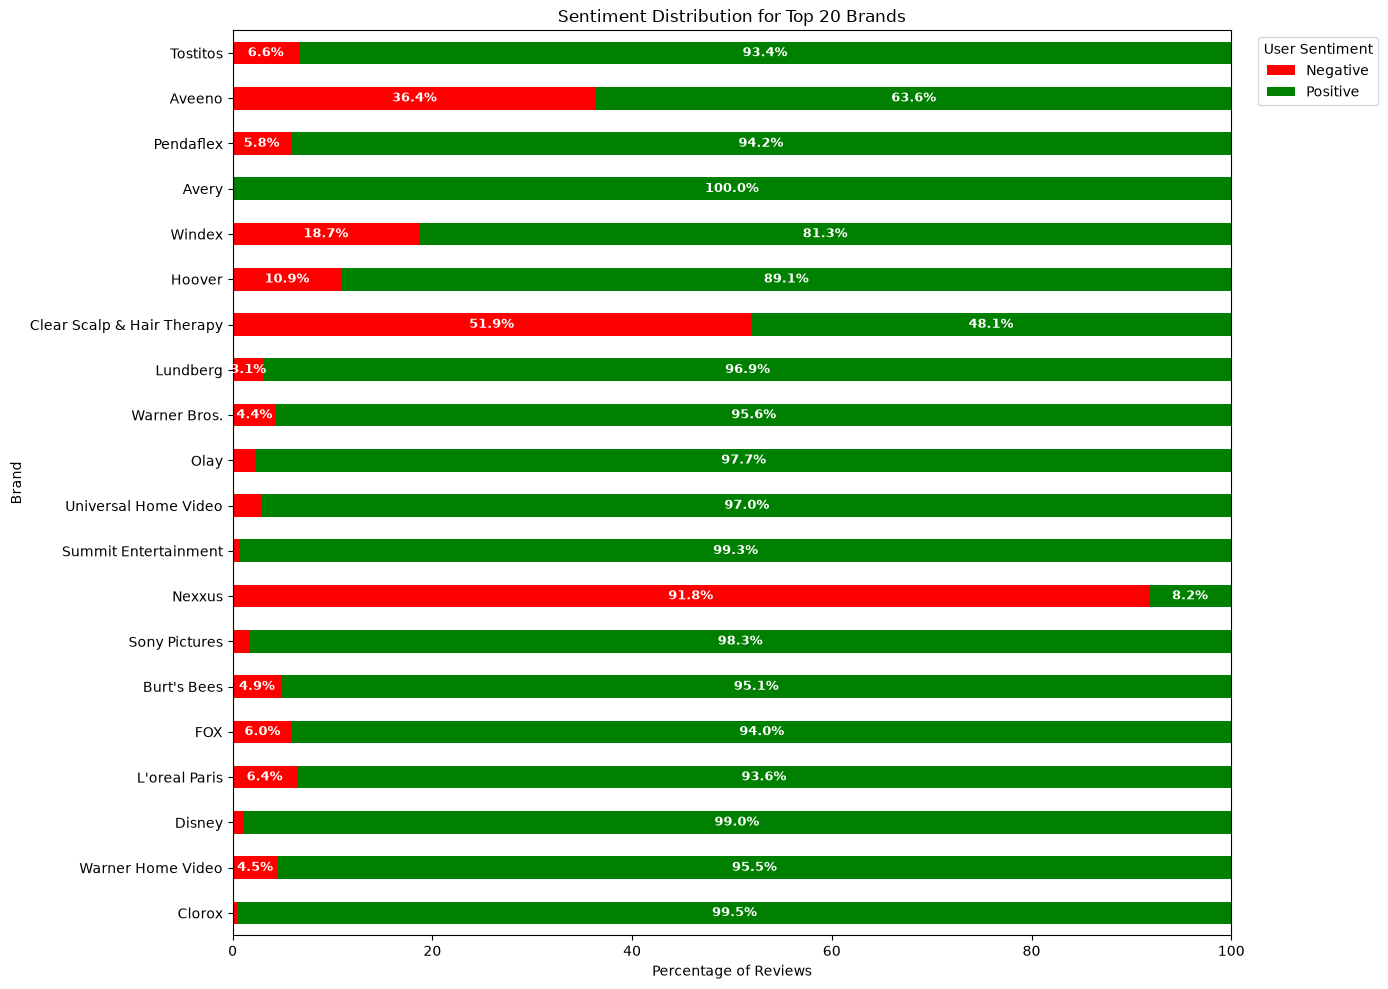

In [389]:
brand_sentiment = (
    reviews_df_cleaned
    .assign(brand=reviews_df_cleaned["brand"].fillna("Unknown"))
    .groupby(["brand", "user_sentiment"])
    .size()
    .unstack(fill_value=0)
)

brand_sentiment["total_reviews"] = brand_sentiment.sum(axis=1)
brand_sentiment = brand_sentiment.sort_values("total_reviews", ascending=False)

top_brand_sentiment = brand_sentiment.head(20)

brand_sentiment_pct = (
    top_brand_sentiment
    .drop(columns="total_reviews")
    .div(top_brand_sentiment["total_reviews"], axis=0)
    .mul(100)
    .round(2)
)

display_info("Sentiment Percentage for Top 20 Brands")
display(brand_sentiment_pct.style.format("{:.2f}%"))

ax = brand_sentiment_pct.plot(
    kind="barh",
    stacked=True,
    figsize=(14, 10),
    color={"Negative": "Red", "Positive": "Green"},
)

for container in ax.containers:
    for bar in container:
        width = bar.get_width()
        if width > 3:
            ax.text(
                bar.get_x() + width / 2,
                bar.get_y() + bar.get_height() / 2,
                f"{width:.1f}%",
                ha="center",
                va="center",
                color="white",
                fontsize=9,
                fontweight="bold",
            )

plt.title("Sentiment Distribution for Top 20 Brands")
plt.xlabel("Percentage of Reviews")
plt.ylabel("Brand")
plt.xlim(0, 100)
plt.legend(title="User Sentiment", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

--------------------------------------------------
Unique product categories: 1281
--------------------------------------------------
--------------------------------------------------
Top 20 common product categories: categories
Movies                       18303
Featured Brands              14653
Health & Household           11287
Household Supplies           11211
Household Essentials         11128
Household Cleaning           11080
Food & Grocery               11079
Home And Storage & Org       11044
Cleaning Supplies            11019
Target Restock               10934
Clorox                       10564
Ways To Shop                  9868
Glass Cleaners                8906
All-Purpose Cleaners          8700
Music & Books                 8575
Surface Care & Protection     8539
Business & Industrial         8538
All Purpose Cleaners          8528
Classroom Essentials          8526
Kitchen Cleaners              8524
Name: count, dtype: int64
--------------------------------------------

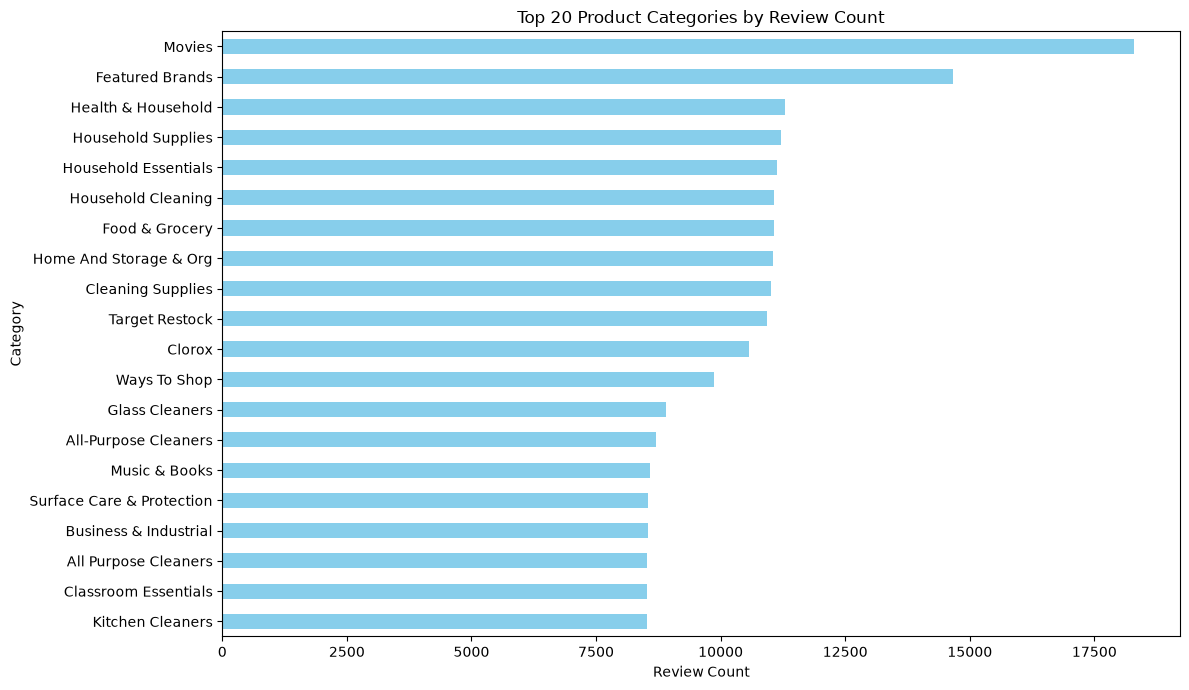

In [380]:
# Identify common product categories by splitting the comma-separated category strings
category_counts = (
    reviews_df_cleaned["categories"]
    .fillna("Missing")
    .astype(str)
    .str.split(",")
    .explode()
    .str.strip()
    .replace("", "Missing")
    .value_counts()
)

display_info(category_counts.shape[0], "Unique product categories")
display_info(category_counts.head(20), "Top 20 common product categories")

plt.figure(figsize=(12, 7))
category_counts.head(20).sort_values(ascending=True).plot(
    kind="barh",
    color="skyblue"
)
plt.title("Top 20 Product Categories by Review Count")
plt.xlabel("Review Count")
plt.ylabel("Category")
plt.tight_layout()
plt.show()

,Negative,Positive,total_reviews,positive_pct,negative_pct,avg_rating,review_count
category,,,,,,,
Movies,610,17690,18300,96.67%,3.33%,4.49,18303
Featured Brands,1214,13439,14653,91.72%,8.28%,4.48,14653
Health & Household,142,11145,11287,98.74%,1.26%,4.80,11287
Household Supplies,130,11081,11211,98.84%,1.16%,4.80,11211
Household Essentials,133,10995,11128,98.80%,1.20%,4.80,11128
Household Cleaning,127,10953,11080,98.85%,1.15%,4.80,11080
Food & Grocery,126,10953,11079,98.86%,1.14%,4.80,11079
Home And Storage & Org,127,10917,11044,98.85%,1.15%,4.80,11044
Cleaning Supplies,128,10891,11019,98.84%,1.16%,4.80,11019


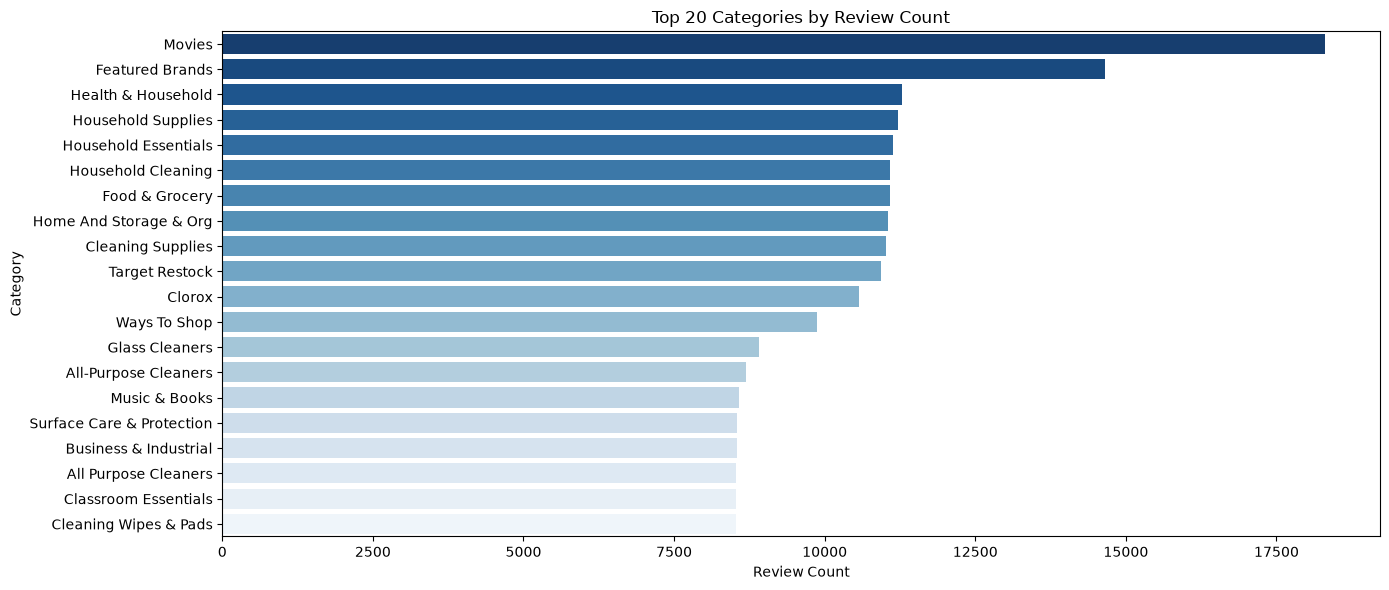

<Figure size 1400x600 with 0 Axes>

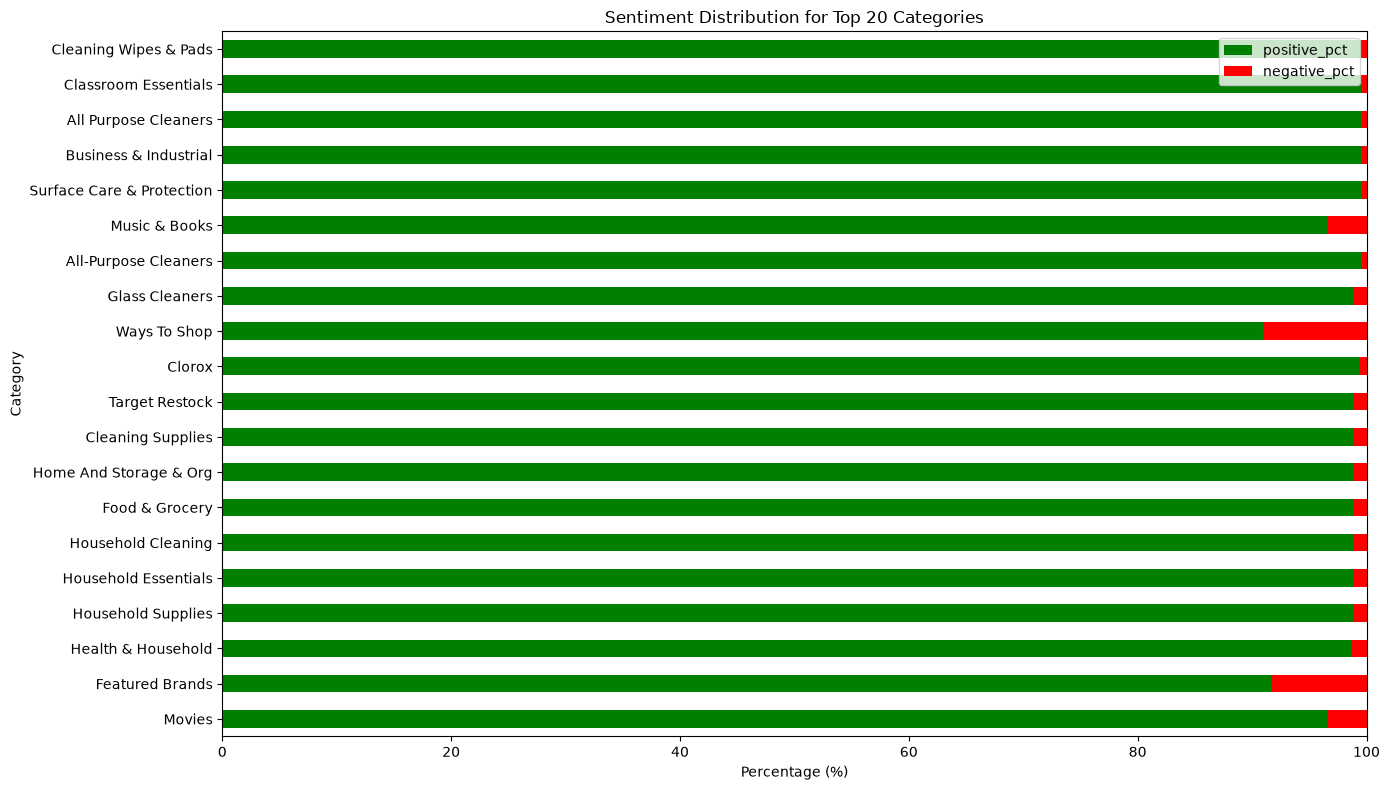

In [381]:
# compare category level sentiment distribution
category_df = (
    reviews_df_cleaned
    .assign(categories=reviews_df_cleaned["categories"].fillna("Missing").astype(str))
    .assign(category=lambda df: df["categories"].str.split(","))
    .explode("category")
    .assign(category=lambda df: df["category"].str.strip().replace("", "Missing"))
)

category_sentiment = (
    category_df
    .groupby(["category", "user_sentiment"])
    .size()
    .unstack(fill_value=0)
)

category_sentiment["total_reviews"] = category_sentiment.sum(axis=1)
category_sentiment["positive_pct"] = (
    category_sentiment["Positive"] / category_sentiment["total_reviews"] * 100
).round(2)
category_sentiment["negative_pct"] = (
    category_sentiment["Negative"] / category_sentiment["total_reviews"] * 100
).round(2)

category_rating = (
    category_df
    .groupby("category")
    .agg(
        avg_rating=("reviews_rating", "mean"),
        review_count=("reviews_rating", "count"),
    )
    .assign(avg_rating=lambda df: df["avg_rating"].round(2))
)

category_summary = (
    category_sentiment
    .join(category_rating)
    .sort_values("review_count", ascending=False)
)

display(category_summary.head(20).style.format({
    "avg_rating": "{:.2f}",
    "positive_pct": "{:.2f}%",
    "negative_pct": "{:.2f}%"
}))

top_categories = category_summary.head(20).reset_index()

plt.figure(figsize=(14, 6))
sns.barplot(
    data=top_categories,
    x="review_count",
    y="category",
    hue="category",
    palette = "Blues_r",
    legend=False
)
plt.title("Top 20 Categories by Review Count")
plt.xlabel("Review Count")
plt.ylabel("Category")
plt.tight_layout()
plt.show()

plt.figure(figsize=(14, 6))
top_categories.plot(
    kind="barh",
    x="category",
    y=["positive_pct", "negative_pct"],
    stacked=True,
    color=["green", "red"],
    legend=True,
    figsize=(14, 8)
)
plt.title("Sentiment Distribution for Top 20 Categories")
plt.xlabel("Percentage (%)")
plt.ylabel("Category")
plt.xlim(0, 100)
plt.tight_layout()
plt.show()

#### Observation

Clorox brand has received the highest number of reviewes (10564) with positive (99.47%) and negative (0.53%) reviews. This is primarily because it makes up 35.68% of the total branded data, leading to a higher volume of feedback overall. 

### 2.9. User-Level Analysis

- Count unique users.
- Analyze reviews per user.
- Identify the most active users.
- Count users with only one review.
- Inspect the rating behavior of active users.

In [382]:
#Count unique users.
display_info(reviews_df_cleaned['reviews_username'].nunique(),"Total No Of Unique Users:")

--------------------------------------------------
Total No Of Unique Users:: 24670
--------------------------------------------------


--------------------------------------------------
Users review distribution: Review counts per user summary
--------------------------------------------------
count    24670.000000
mean         1.200122
std          0.757440
min          1.000000
25%          1.000000
50%          1.000000
75%          1.000000
max         41.000000
--------------------------------------------------
Users with exactly 1 review:: 21086
--------------------------------------------------
--------------------------------------------------
Users with more than 1 review: : 3584
--------------------------------------------------
--------------------------------------------------
Users with 5 or more reviews:: 147
--------------------------------------------------
--------------------------------------------------
Users with 10 or more reviews:: 23
--------------------------------------------------
--------------------------------------------------
Top 20 most active users by review count: 
------------------

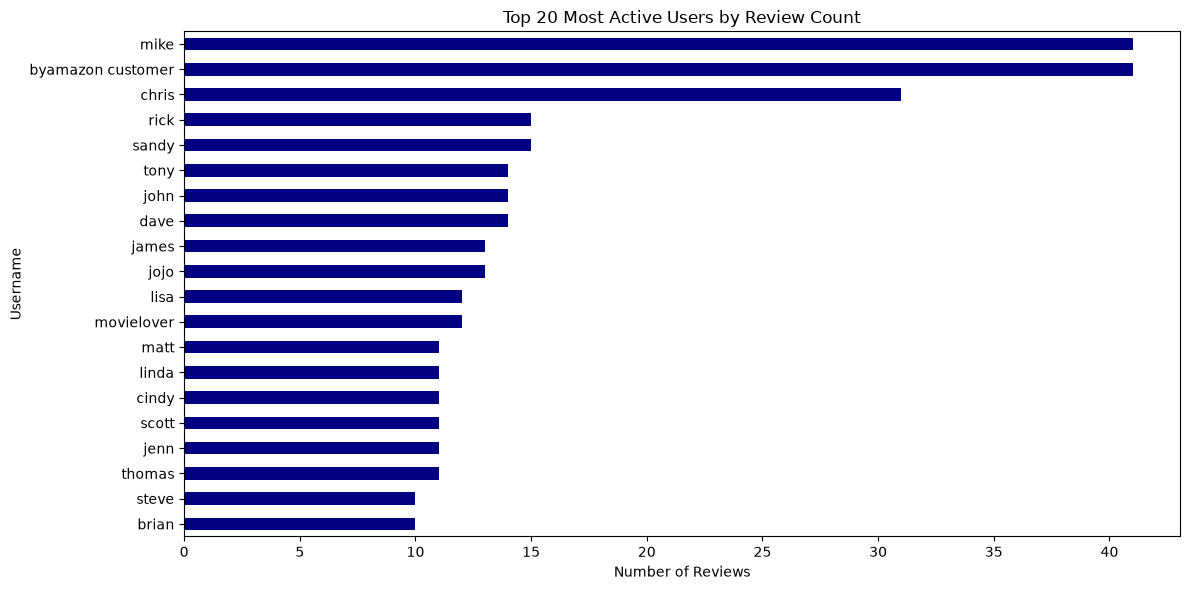

In [383]:
# Analyze review counts per user
user_review_counts = reviews_df_cleaned["reviews_username"].value_counts()

review_summary = user_review_counts.describe()
single_review_users = (user_review_counts == 1).sum()
multi_review_users = (user_review_counts > 1).sum()
users_5plus = (user_review_counts >= 5).sum()
users_10plus = (user_review_counts >= 10).sum()

display_info("Review counts per user summary", "Users review distribution")
print(review_summary.to_string())
display_info(single_review_users,"Users with exactly 1 review:")
display_info(multi_review_users,"Users with more than 1 review: ")
display_info(users_5plus,"Users with 5 or more reviews:")
display_info(users_10plus,"Users with 10 or more reviews:")

display_info("", "Top 20 most active users by review count")
# display(user_review_counts.head(20))

# Plot top users
plt.figure(figsize=(12, 6))
user_review_counts.head(20).sort_values().plot(
    kind="barh",
    color="navy"
)
plt.title("Top 20 Most Active Users by Review Count")
plt.xlabel("Number of Reviews")
plt.ylabel("Username")
plt.tight_layout()
plt.show()

--------------------------------------------------
Active users with ≥5 reviews: 147
--------------------------------------------------


,review_count,avg_rating,min_rating,max_rating,std_rating,pct_5_star,pct_1_star
reviews_username,,,,,,,
mike,41,4.41,1,5,1.00,63.41,4.88
byamazon customer,41,3.95,1,5,1.67,65.85,21.95
chris,31,4.55,2,5,0.77,67.74,0.00
rick,15,4.47,1,5,1.13,73.33,6.67
sandy,15,4.47,1,5,1.41,86.67,13.33
john,14,4.71,3,5,0.61,78.57,0.00
tony,14,4.57,3,5,0.65,64.29,0.00
dave,14,3.93,1,5,1.64,57.14,21.43
jojo,13,4.77,4,5,0.44,76.92,0.00


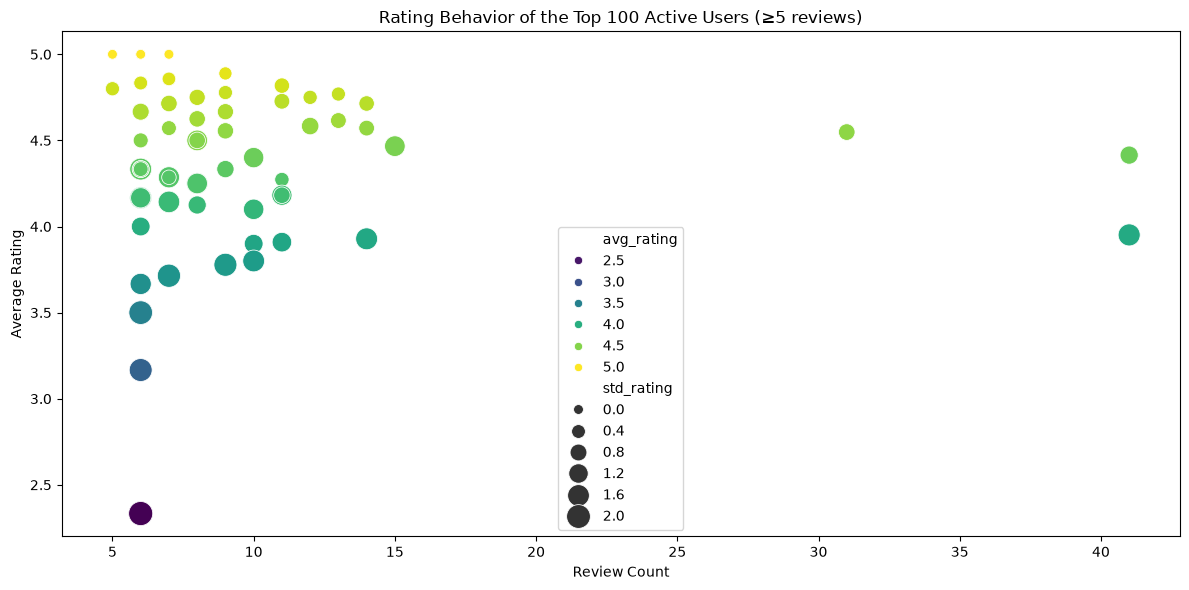

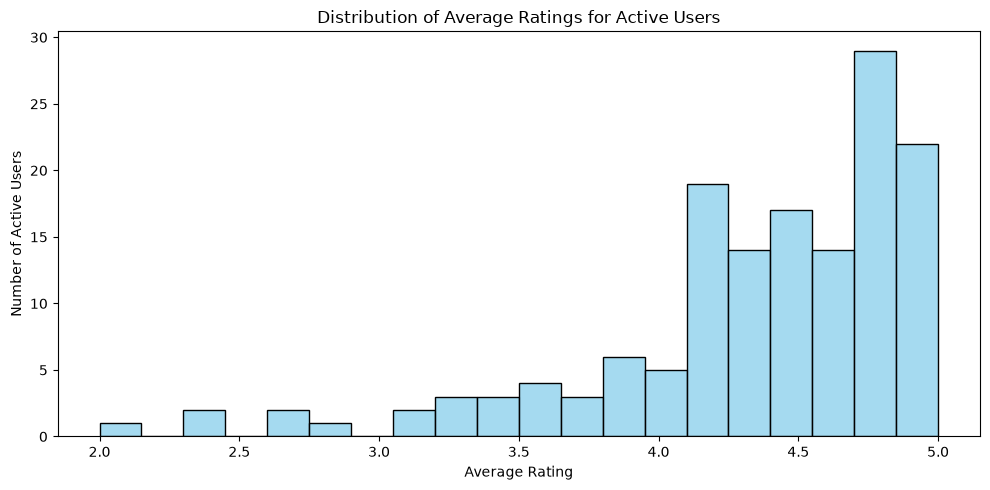

In [384]:
active_user_threshold = 5

active_users = user_review_counts[user_review_counts >= active_user_threshold].index

active_user_rating_behavior = (
    reviews_df_cleaned[reviews_df_cleaned["reviews_username"].isin(active_users)]
    .groupby("reviews_username")
    .agg(
        review_count=("reviews_rating", "count"),
        avg_rating=("reviews_rating", "mean"),
        min_rating=("reviews_rating", "min"),
        max_rating=("reviews_rating", "max"),
        std_rating=("reviews_rating", "std"),
        pct_5_star=("reviews_rating", lambda x: (x == 5).mean() * 100),
        pct_1_star=("reviews_rating", lambda x: (x == 1).mean() * 100),
    )
    .sort_values(["review_count", "avg_rating"], ascending=[False, False])
)

display_info(len(active_users), f"Active users with ≥{active_user_threshold} reviews")
display(
    active_user_rating_behavior.head(20).round(
        {"avg_rating": 2, "std_rating": 2, "pct_5_star": 2, "pct_1_star": 2}
    )
)

plt.figure(figsize=(12, 6))
sns.scatterplot(
    data=active_user_rating_behavior.reset_index().head(100),
    x="review_count",
    y="avg_rating",
    size="std_rating",
    hue="avg_rating",
    palette="viridis",
    sizes=(50, 300),
    legend="brief",
)
plt.title(f"Rating Behavior of the Top 100 Active Users (≥{active_user_threshold} reviews)")
plt.xlabel("Review Count")
plt.ylabel("Average Rating")
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 5))
sns.histplot(active_user_rating_behavior["avg_rating"], bins=20, color="skyblue")
plt.title("Distribution of Average Ratings for Active Users")
plt.xlabel("Average Rating")
plt.ylabel("Number of Active Users")
plt.tight_layout()
plt.show()

### 11. Date Analysis

- Convert `reviews_date` to datetime.
- Check the available date range.
- Analyze review counts over time.
- Analyze rating trends over time.
- Analyze sentiment trends over time.

In [ ]:
# Convert the reviews_date to datetime.
reviews_df_cleaned.info()
reviews_df_cleaned['reviews_date']= pd.to_datetime(reviews_df_cleaned['reviews_date'],errors='coerce')
display_info("","After changing to datetime:")
reviews_df_cleaned.info()

<class 'pandas.DataFrame'>
Index: 29607 entries, 0 to 29999
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype              
---  ------            --------------  -----              
 0   id                29607 non-null  str                
 1   brand             29607 non-null  str                
 2   categories        29607 non-null  str                
 3   manufacturer      29607 non-null  str                
 4   name              29607 non-null  str                
 5   reviews_date      29043 non-null  datetime64[us, UTC]
 6   reviews_rating    29607 non-null  int64              
 7   reviews_text      29607 non-null  str                
 8   reviews_title     29607 non-null  str                
 9   reviews_username  29607 non-null  str                
 10  user_sentiment    29606 non-null  str                
dtypes: datetime64[us, UTC](1), int64(1), str(9)
memory usage: 3.7 MB
--------------------------------------------------
After changing to d

### 7. Review Text Analysis & preprocessing

- Check missing, empty, or very short reviews.
- Calculate review length by characters and words.
- Compare review length across sentiment classes.
- Inspect common words before preprocessing.
- Identify text quality issues such as casing, punctuation, special characters, URLs, HTML, or noisy tokens.

In [385]:
# Placeholder for cleanup decisions after reviewing duplicate patterns.







### 12. Recommendation-Relevant EDA

- Count unique users and products available for recommendation.
- Create a user-product rating matrix preview.
- Calculate the rating matrix sparsity.
- Identify users and products with too few ratings.
- Confirm that `reviews_username`, `name`, and `reviews_rating` have enough usable coverage for collaborative filtering.

### 13. Final EDA Summary

- Summarize columns to use for sentiment modeling.
- Summarize columns to use for recommendation modeling.
- Summarize columns that should be dropped or ignored.
- Document missing value handling decisions.
- Document text preprocessing decisions.
- Document class imbalance observations.
- Document recommendation strategy considerations.

## Suggested Final Workflow

1. Load and inspect the reviews dataset.
2. Clean and preprocess review text.
3. Extract text features.
4. Train and compare at least three sentiment classifiers.
5. Select the best sentiment model.
6. Build user-based and item-based collaborative filtering recommenders.
7. Evaluate both recommenders and select the better one.
8. Generate top 20 product recommendations for a given username.
9. Score or filter the top 20 products using the sentiment model.
10. Return the final top 5 products through a Flask UI.
